In [1]:
pip install geopandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
print(gpd.__version__)


1.1.4


In [3]:
import geopandas as gpd
print("GeoPandas is ready!")


GeoPandas is ready!


In [4]:
!pip install geodatasets matplotlib


In [5]:
import geopandas as gpd
import geodatasets

# 1. Fetch the remote path for the built-in world map dataset
world_path = geodatasets.get_path("naturalearth.lowres")

# 2. Read the geographic file into a GeoDataFrame
world = gpd.read_file(world_path)

# 3. Plot the data instantly
world.plot(figsize=(10, 6), edgecolor="black", color="lightblue")


C:\Users\cason\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: No matching item found for the query 'naturalearth.lowres'.

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Direct link to a stable, low-resolution public world dataset
world_url = "https://naciscdn.org"

# 2. Read the geographic dataset straight from the web
world = gpd.read_file(world_url)

# 3. Plot the data
world.plot(figsize=(10, 6), edgecolor="black", color="lightblue")
plt.show()


DataSourceError: '/vsimem/pyogrio_e2d08c0980974c5293864631d8222b4d' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Read your downloaded shapefile directly from your folder
raw_landmarks = gpd.read_file("C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw")

# 2. Filter the attribute table column to keep only State Parks
georgia_parks = raw_landmarks[raw_landmarks['NAME'].str.contains("State Park", na=False)]

# 3. View the first 5 records of your clean data table
print(georgia_parks[['NAME', 'geometry']].head())

# 4. Plot the park boundaries visually
fig, ax = plt.subplots(figsize=(10, 10))
georgia_parks.plot(ax=ax, facecolor="forestgreen", edgecolor="black", alpha=0.8)
plt.title("Georgia State Parks Geographic Map")
plt.show()


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1527672352.py, line 5)

In [9]:
import geopandas as gpd
raw_landmarks = gpd.read_file("tl_2023_13_arealm.zip")
print("Successfully loaded rows:", len(raw_landmarks))


Successfully loaded rows: 4549


In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Read your uploaded geographic archive directly
raw_landmarks = gpd.read_file("tl_2023_13_arealm.zip")

# 2. Filter the attribute rows to isolate GA State Parks
georgia_parks = raw_landmarks[raw_landmarks['NAME'].str.contains("State Park", na=False)]

# 3. View the record count and top rows
print("State Parks Cleaned and Loaded:", len(georgia_parks))

# 4. Generate the map layout canvas
fig, ax = plt.subplots(figsize=(10, 10))
georgia_parks.plot(ax=ax, facecolor="forestgreen", edgecolor="black", alpha=0.8)
plt.title("Georgia State Parks Boundaries Map")
plt.axis("on")
plt.show()


KeyError: 'NAME'

In [11]:
import geopandas as gpd
raw_landmarks = gpd.read_file("tl_2023_13_arealm.zip")

# Print all available column names
print(raw_landmarks.columns)


Index(['STATEFP', 'ANSICODE', 'AREAID', 'FULLNAME', 'MTFCC', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'PARTFLG', 'geometry'],
      dtype='str')


Using column 'FULLNAME'. State Parks found: 29


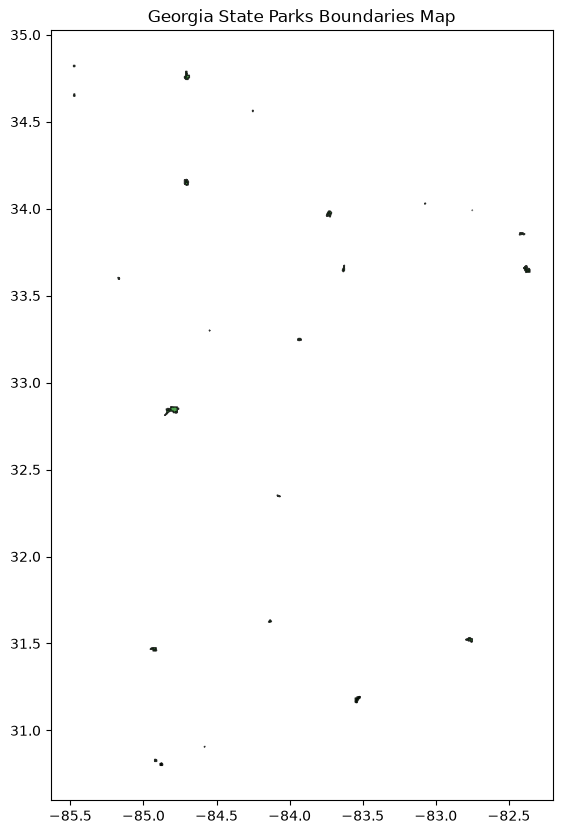

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Read your uploaded geographic archive directly
raw_landmarks = gpd.read_file("tl_2023_13_arealm.zip")

# 2. Automatically identify if the column is named 'FULLNAME' or 'NAME'
name_col = 'FULLNAME' if 'FULLNAME' in raw_landmarks.columns else 'NAME'

# 3. Filter the dataset to isolate State Parks using the correct column
georgia_parks = raw_landmarks[raw_landmarks[name_col].str.contains("State Park", na=False)]

# 4. Confirm it worked
print(f"Using column '{name_col}'. State Parks found: {len(georgia_parks)}")

# 5. Generate the map canvas
fig, ax = plt.subplots(figsize=(10, 10))
georgia_parks.plot(ax=ax, facecolor="forestgreen", edgecolor="black", alpha=0.8)
plt.title("Georgia State Parks Boundaries Map")
plt.axis("on")
plt.show()


In [13]:
# Save your clean state parks map to your hard drive
georgia_parks.to_file("georgia_state_parks.gpkg", driver="GPKG")

print("Export complete! Check your notebook folder for 'georgia_state_parks.gpkg'.")


Export complete! Check your notebook folder for 'georgia_state_parks.gpkg'.


In [1]:
pip install pygris

Note: you may need to restart the kernel to use updated packages.


Using FIPS code '06' for input 'CA'
  STATEFP COUNTYFP TRACTCE              AFFGEOID        GEOID   NAME  \
0      06      077  005127  1400000US06077005127  06077005127  51.27   
1      06      077  003406  1400000US06077003406  06077003406  34.06   
2      06      077  004402  1400000US06077004402  06077004402  44.02   
3      06      077  001700  1400000US06077001700  06077001700     17   
4      06      077  000401  1400000US06077000401  06077000401   4.01   

             NAMELSAD STUSPS          NAMELSADCO  STATE_NAME LSAD    ALAND  \
0  Census Tract 51.27     CA  San Joaquin County  California   CT  1960015   
1  Census Tract 34.06     CA  San Joaquin County  California   CT   839414   
2  Census Tract 44.02     CA  San Joaquin County  California   CT  4346363   
3     Census Tract 17     CA  San Joaquin County  California   CT  1685934   
4   Census Tract 4.01     CA  San Joaquin County  California   CT  1045658   

   AWATER                                           geometry  

<Axes: >

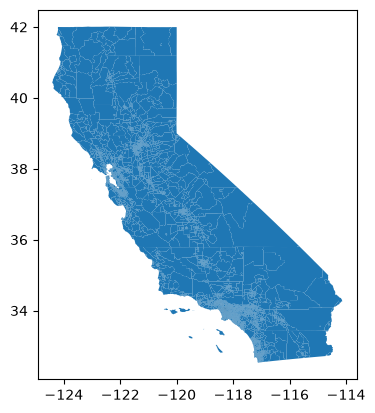

In [2]:
import pygris

# Fetch census tracts for California
# Setting cb=True downloads the simplified Cartographic Boundary files, which are smaller and load faster
ca_tracts = pygris.tracts(state="CA", cb=True, year=2022)

# The result is a standard GeoDataFrame ready for spatial analysis
print(ca_tracts.head())
ca_tracts.plot()

Using FIPS code '13' for input 'GA'
  STATEFP COUNTYFP TRACTCE              AFFGEOID        GEOID    NAME  \
0      13      101  880100  1400000US13101880100  13101880100    8801   
1      13      185  011100  1400000US13185011100  13185011100     111   
2      13      277  960700  1400000US13277960700  13277960700    9607   
3      13      095  001500  1400000US13095001500  13095001500      15   
4      13      095  010402  1400000US13095010402  13095010402  104.02   

              NAMELSAD STUSPS        NAMELSADCO STATE_NAME LSAD      ALAND  \
0    Census Tract 8801     GA     Echols County    Georgia   CT  873494768   
1     Census Tract 111     GA    Lowndes County    Georgia   CT    1957360   
2    Census Tract 9607     GA       Tift County    Georgia   CT   24158997   
3      Census Tract 15     GA  Dougherty County    Georgia   CT    1944375   
4  Census Tract 104.02     GA  Dougherty County    Georgia   CT   24626133   

   AWATER                                           geom

<Axes: >

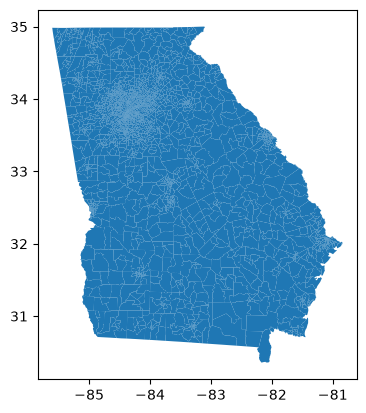

In [3]:
import pygris

# Fetch census tracts for California
# Setting cb=True downloads the simplified Cartographic Boundary files, which are smaller and load faster
ca_tracts = pygris.tracts(state="GA", cb=True, year=2022)

# The result is a standard GeoDataFrame ready for spatial analysis
print(ca_tracts.head())
ca_tracts.plot()

In [4]:
import os

# Create a dedicated folder for the shapefile components
os.makedirs("georgia_census_data", exist_ok=True)

# Export the GeoDataFrame as a shapefile
ca_tracts.to_file("georgia_census_data/ga_tracts.shp")

In [ ]:
import os

# Check if the folder exists and list its contents
if os.path.exists("california_census_data"):
    print("Folder found! Here are the files inside:")
    print(os.listdir("california_census_data"))
else:
    print("Folder not found. The export might not have run correctly.")

In [5]:
import geopandas as gpd

counties = gpd.read_file("data/raw/counties/tl_2025_13_county.shp")

counties.head()

DataSourceError: data/raw/counties/tl_2025_13_county.shp: No such file or directory

In [6]:
import geopandas as gpd

counties = gpd.read_file("C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\tlgdb_2025_a_13_ga_edges.gdb.zip")

counties.head()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1362204660.py, line 3)

In [8]:
counties = gpd.read_file("../data/raw/counties/tl_2025_13_county.shp")

DataSourceError: ../data/raw/counties/tl_2025_13_county.shp: No such file or directory

In [9]:
counties = gpd.read_file("C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties")

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (410016857.py, line 1)

In [10]:
counties = gpd.read_file(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties")

DataSourceError: C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties: Permission denied

In [11]:
import os

os.listdir(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties")

['tl_2025_us_county']

In [12]:
os.listdir(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties\tl_2025_us_county")

['tl_2025_us_county.cpg',
 'tl_2025_us_county.dbf',
 'tl_2025_us_county.prj',
 'tl_2025_us_county.shp',
 'tl_2025_us_county.shp.ea.iso.xml',
 'tl_2025_us_county.shp.iso.xml',
 'tl_2025_us_county.shx']

In [13]:
counties.head()

NameError: name 'counties' is not defined

In [14]:
%whos

Variable    Type            Data/Info
-------------------------------------
ca_tracts   GeoDataFrame         STATEFP COUNTYFP TRA<...>n[2791 rows x 14 columns]
gpd         module          <module 'geopandas' from <...>\geopandas\\__init__.py'>
os          module          <module 'os' (frozen)>
pygris      module          <module 'pygris' from 'C:<...>es\\pygris\\__init__.py'>


In [15]:
import geopandas as gpd

counties = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties\tl_2025_us_county\tl_2025_us_county.shp"
)

In [16]:
counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,NaN,NaN,NaN,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-98.95506 35.11643, -98.94903 35.116..."
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,NaN,NaN,NaN,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-96.88886 43.9353, -96.88886 43.9351..."
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,NaN,NaN,NaN,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((-79.14343 36.4422, -79.14345 36.4418..."
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,NaN,NaN,NaN,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-104.98078 30.62552, -104.98073 30.6..."
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,212,19430,NaN,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((-84.10668 39.68891, -84.10662 39.689..."


In [17]:
type(counties)

geopandas.geodataframe.GeoDataFrame

In [18]:
len(counties)

3235

In [19]:
counties.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

<Axes: >

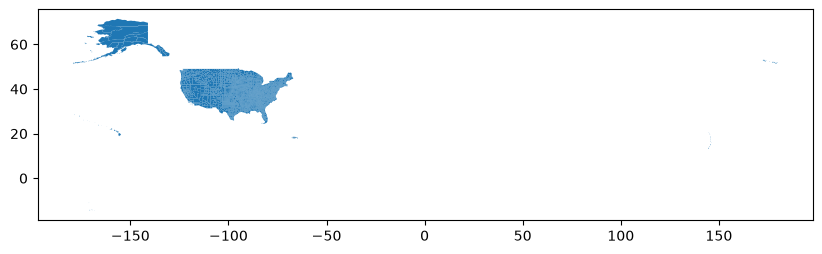

In [20]:
counties.plot(figsize=(10, 10))

<Axes: >

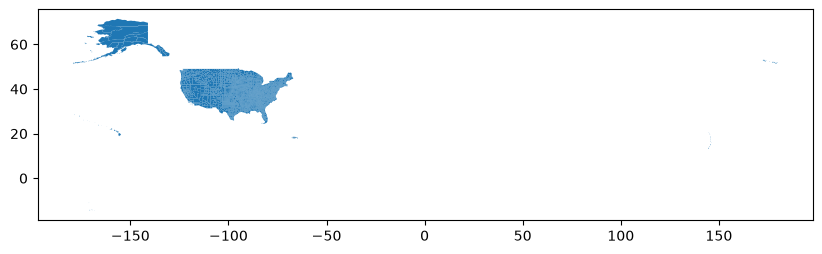

In [21]:
counties.head()

type(counties)

len(counties)

counties.crs

counties.plot(figsize=(10,10))

In [22]:
counties.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [23]:
ga_counties = counties[counties["STATEFP"] == "13"]

In [24]:
counties["STATEFP"]

0       40
1       46
2       37
3       48
4       39
        ..
3230    53
3231    19
3232    31
3233    28
3234    12
Name: STATEFP, Length: 3235, dtype: str

In [25]:
counties["STATEFP"] == "13"

0       False
1       False
2       False
3       False
4       False
        ...  
3230    False
3231    False
3232    False
3233    False
3234    False
Name: STATEFP, Length: 3235, dtype: bool

In [26]:
counties[ ... ]

KeyError: Ellipsis

In [27]:
ga_counties = counties[counties["STATEFP"] == "13"]

In [28]:
len(ga_counties)

159

<Axes: >

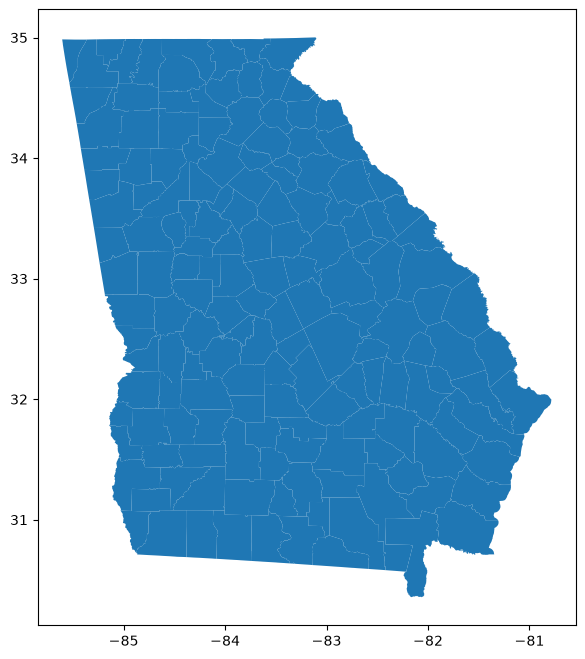

In [29]:
ga_counties.plot(figsize=(8,8))

In [30]:
ga_counties.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\ga_counties.shp"
)

In [31]:
del ga_counties

In [32]:
ga_counties = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\ga_counties.shp"
)

In [33]:
parks.head()

NameError: name 'parks' is not defined

In [34]:
import geopandas as gpd

In [35]:
parks = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\parks\YOUR_FILE_NAME.shp"
)

DataSourceError: C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\parks\YOUR_FILE_NAME.shp: No such file or directory

In [36]:
import pandas as pd

In [37]:
population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census\YOUR_FILE.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity\\data\\raw\\census\\YOUR_FILE.csv'

In [38]:
import os

os.listdir(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census"
)

['ACSDT5Y2024.B01003-2026-07-12T023857.csv']

In [39]:
population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census\population.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity\\data\\raw\\census\\population.csv'

In [40]:
population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census\ACSDT5Y2024.B01003-2026-07-12T023857.csv"
)

In [41]:
population

,Label (Grouping),United States!!Estimate,United States!!Margin of Error
0,Total,"334,922,499",*****


In [42]:
population.head()

,Label (Grouping),United States!!Estimate,United States!!Margin of Error
0,Total,"334,922,499",*****


In [43]:
import pandas as pd

In [44]:
population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census\population.csv"
)

In [45]:
population.head()

,Label (Grouping),"Appling County, Georgia!!Estimate","Appling County, Georgia!!Margin of Error","Atkinson County, Georgia!!Estimate","Atkinson County, Georgia!!Margin of Error","Bacon County, Georgia!!Estimate","Bacon County, Georgia!!Margin of Error","Baker County, Georgia!!Estimate","Baker County, Georgia!!Margin of Error","Baldwin County, Georgia!!Estimate",...,"Whitfield County, Georgia!!Estimate","Whitfield County, Georgia!!Margin of Error","Wilcox County, Georgia!!Estimate","Wilcox County, Georgia!!Margin of Error","Wilkes County, Georgia!!Estimate","Wilkes County, Georgia!!Margin of Error","Wilkinson County, Georgia!!Estimate","Wilkinson County, Georgia!!Margin of Error","Worth County, Georgia!!Estimate","Worth County, Georgia!!Margin of Error"
0,Total,"18,426",*****,"8,261",*****,"11,129",*****,"2,830",*****,"43,669",...,"103,118",*****,"8,784",*****,"9,553",*****,"8,795",*****,"20,575",*****


In [46]:
import pandas as pd

# Load your CSV
population = pd.read_csv("your_file_name.csv")

# Look at the first few rows
population.head()

FileNotFoundError: [Errno 2] No such file or directory: 'your_file_name.csv'

In [47]:
import pandas as pd

# Load your CSV
population = pd.read_csv("population.csv")

# Look at the first few rows
population.head()

FileNotFoundError: [Errno 2] No such file or directory: 'population.csv'

In [48]:
import pandas as pd

# Load your CSV
population = pd.read_csv("population.csv")

# Look at the first few rows
population.head()

FileNotFoundError: [Errno 2] No such file or directory: 'population.csv'

In [49]:
import os

os.getcwd()

'C:\\Users\\cason'

In [50]:
'C:\\Users\\cason'

'C:\\Users\\cason'

In [ ]:
population = pd.read_csv(
    r"C:\Users\cason\Downloads\Y.csv"
)

population.head()

In [51]:
import os

os.listdir(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census")

['ACSDT5Y2024.B01003-2026-07-12T023857.csv', 'population.csv']

In [52]:
population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\census\population.csv"
)

population.head()

,Label (Grouping),"Appling County, Georgia!!Estimate","Appling County, Georgia!!Margin of Error","Atkinson County, Georgia!!Estimate","Atkinson County, Georgia!!Margin of Error","Bacon County, Georgia!!Estimate","Bacon County, Georgia!!Margin of Error","Baker County, Georgia!!Estimate","Baker County, Georgia!!Margin of Error","Baldwin County, Georgia!!Estimate",...,"Whitfield County, Georgia!!Estimate","Whitfield County, Georgia!!Margin of Error","Wilcox County, Georgia!!Estimate","Wilcox County, Georgia!!Margin of Error","Wilkes County, Georgia!!Estimate","Wilkes County, Georgia!!Margin of Error","Wilkinson County, Georgia!!Estimate","Wilkinson County, Georgia!!Margin of Error","Worth County, Georgia!!Estimate","Worth County, Georgia!!Margin of Error"
0,Total,"18,426",*****,"8,261",*****,"11,129",*****,"2,830",*****,"43,669",...,"103,118",*****,"8,784",*****,"9,553",*****,"8,795",*****,"20,575",*****


In [53]:
# Keep only population estimate columns
population_est = population.filter(like="Estimate")

population_est.head()

,"Appling County, Georgia!!Estimate","Atkinson County, Georgia!!Estimate","Bacon County, Georgia!!Estimate","Baker County, Georgia!!Estimate","Baldwin County, Georgia!!Estimate","Banks County, Georgia!!Estimate","Barrow County, Georgia!!Estimate","Bartow County, Georgia!!Estimate","Ben Hill County, Georgia!!Estimate","Berrien County, Georgia!!Estimate",...,"Washington County, Georgia!!Estimate","Wayne County, Georgia!!Estimate","Webster County, Georgia!!Estimate","Wheeler County, Georgia!!Estimate","White County, Georgia!!Estimate","Whitfield County, Georgia!!Estimate","Wilcox County, Georgia!!Estimate","Wilkes County, Georgia!!Estimate","Wilkinson County, Georgia!!Estimate","Worth County, Georgia!!Estimate"
0,"18,426","8,261","11,129","2,830","43,669","18,757","86,982","111,153","17,138","18,257",...,"19,893","30,519","2,348","7,434","28,454","103,118","8,784","9,553","8,795","20,575"


In [54]:
population_long = population_est.T.reset_index()

population_long.head()

,index,0
0,"Appling County, Georgia!!Estimate","18,426"
1,"Atkinson County, Georgia!!Estimate","8,261"
2,"Bacon County, Georgia!!Estimate","11,129"
3,"Baker County, Georgia!!Estimate","2,830"
4,"Baldwin County, Georgia!!Estimate","43,669"


In [55]:
population_long.columns = ["County", "Population"]

population_long.head()

,County,Population
0,"Appling County, Georgia!!Estimate","18,426"
1,"Atkinson County, Georgia!!Estimate","8,261"
2,"Bacon County, Georgia!!Estimate","11,129"
3,"Baker County, Georgia!!Estimate","2,830"
4,"Baldwin County, Georgia!!Estimate","43,669"


In [56]:
population_long["County"] = (
    population_long["County"]
    .str.replace(", Georgia!!Estimate", "", regex=False)
)

population_long.head()

,County,Population
0,Appling County,"18,426"
1,Atkinson County,"8,261"
2,Bacon County,"11,129"
3,Baker County,"2,830"
4,Baldwin County,"43,669"


In [57]:
population_long.to_csv(
    r"data\processed\georgia_county_population.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: 'data\processed'

In [ ]:
population_long.to_csv(
    r"data\processed\georgia_county_population.csv",
    index=False
)

In [58]:
population_long.to_csv(
    r"data\processed\georgia_county_population.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: 'data\processed'

In [59]:
import os

os.makedirs("data/processed", exist_ok=True)

In [60]:
population_long.to_csv(
    r"data\processed\georgia_county_population.csv",
    index=False
)

In [61]:
os.listdir("data/processed")

['georgia_county_population.csv']

In [62]:
import os

os.getcwd()

'C:\\Users\\cason'

In [63]:
import os

os.chdir(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity"
)

In [64]:
os.getcwd()

'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity'

In [65]:
os.listdir()

['data', 'maps', 'NEGA State Park Access.qgz']

In [66]:
os.listdir("data")

['processed', 'raw']

In [67]:
population_long.to_csv(
    r"data\processed\georgia_county_population.csv",
    index=False
)

In [68]:
os.listdir("data/processed")

['ga_counties.cpg',
 'ga_counties.dbf',
 'ga_counties.prj',
 'ga_counties.shp',
 'ga_counties.shx',
 'georgia_county_population.csv']

In [69]:
counties.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [70]:
counties["NAME"].head()

0       Kiowa
1        Lake
2     Caswell
3    Presidio
4      Greene
Name: NAME, dtype: str

In [71]:
counties["NAME"].head()

0       Kiowa
1        Lake
2     Caswell
3    Presidio
4      Greene
Name: NAME, dtype: str

In [72]:
counties["NAME"].head()

0       Kiowa
1        Lake
2     Caswell
3    Presidio
4      Greene
Name: NAME, dtype: str

In [73]:
counties.shape

(3235, 19)

In [74]:
counties.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [75]:
ga_counties = counties[counties["STATEFP"] == "13"]

In [76]:
ga_counties.shape

(159, 19)

<Axes: >

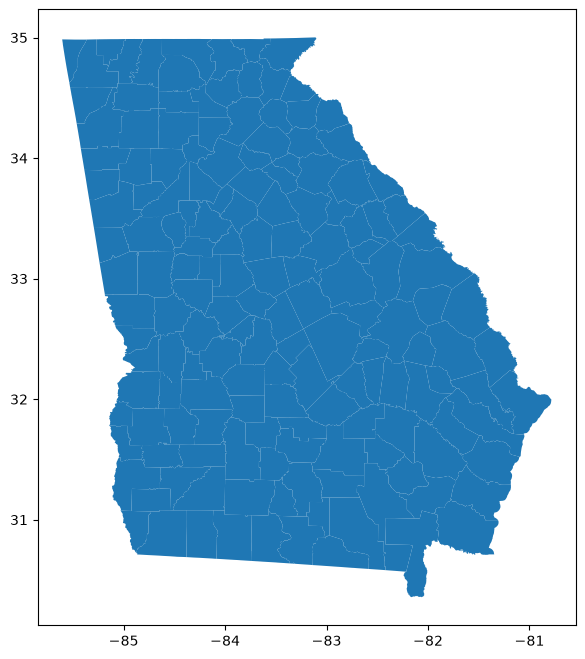

In [77]:
ga_counties.plot(figsize=(8,8))

<Axes: >

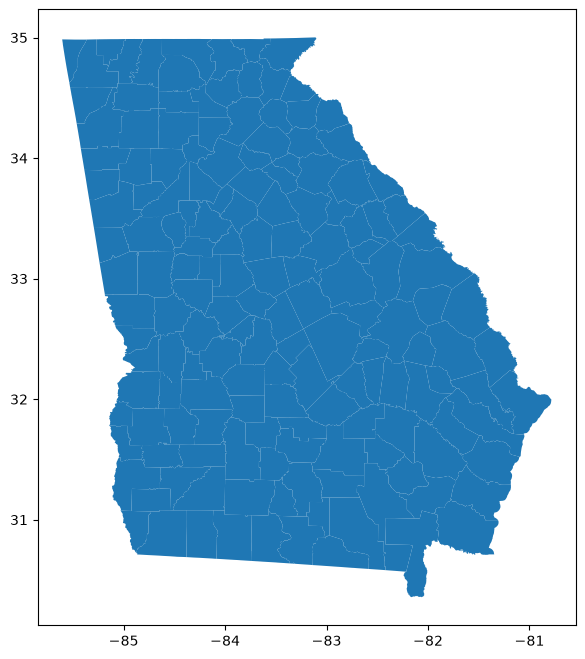

In [78]:
ga_counties.plot(figsize=(8,8))

In [79]:
ga_population = ga_counties.merge(
    population_long,
    on="County",
    how="left"
)

KeyError: 'County'

In [80]:
ga_counties.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')

In [81]:
ga_counties["County"] = ga_counties["NAME"] + " County"

In [82]:
ga_counties[["NAME", "County"]].head()

,NAME,County
11,Effingham,Effingham County
29,Schley,Schley County
61,Hart,Hart County
90,Oconee,Oconee County
97,Brooks,Brooks County


In [83]:
ga_population = ga_counties.merge(
    population_long,
    on="County",
    how="left"
)

In [84]:
ga_population.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,County,Population
0,13,103,00350219,13103,0500000US13103,Effingham,Effingham County,06,H1,G4020,...,42340,NaN,A,1240312876,10401161,+32.3616793,-081.3433755,"POLYGON ((-81.54801 32.48929, -81.54779 32.489...",Effingham County,"67,265"
1,13,249,00344129,13249,0500000US13249,Schley,Schley County,06,H1,G4020,...,11140,NaN,A,432291203,2369649,+32.2634439,-084.3227083,"POLYGON ((-84.36322 32.39765, -84.35627 32.397...",Schley County,"4,539"
2,13,147,01687995,13147,0500000US13147,Hart,Hart County,06,H1,G4020,...,NaN,NaN,A,601973864,63518171,+34.3487324,-082.9632902,"POLYGON ((-83.10706 34.34472, -83.10704 34.344...",Hart County,"26,484"
3,13,219,00356774,13219,0500000US13219,Oconee,Oconee County,06,H1,G4020,...,12020,NaN,A,477493473,5214512,+33.8341247,-083.4377284,"POLYGON ((-83.64703 33.9062, -83.64693 33.9062...",Oconee County,"42,788"
4,13,027,00345518,13027,0500000US13027,Brooks,Brooks County,06,H1,G4020,...,46660,NaN,A,1277341890,11955148,+30.8229337,-083.5819054,"MULTIPOLYGON (((-83.43759 30.81436, -83.43857 ...",Brooks County,"16,285"


In [85]:
ga_population["Population"].isna().sum()

np.int64(0)

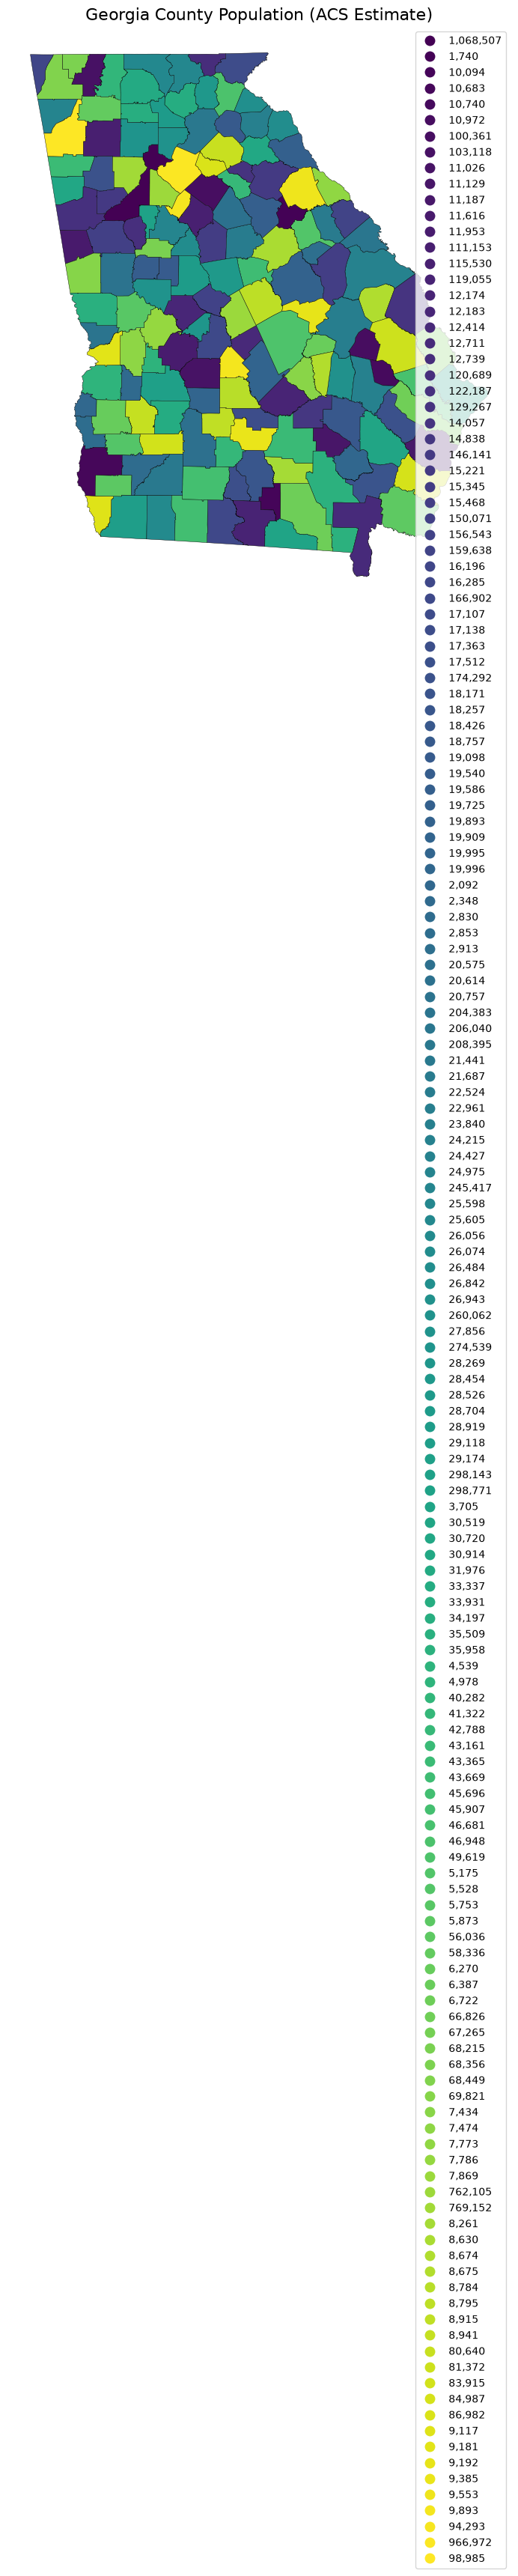

In [86]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

ga_population.plot(
    column="Population",
    cmap="viridis",
    legend=True,
    linewidth=0.3,
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "Georgia County Population (ACS Estimate)",
    fontsize=16
)

ax.axis("off")

plt.show()

In [87]:
fig.savefig(
    r"maps\georgia_county_population.png",
    dpi=300,
    bbox_inches="tight"
)

In [88]:
ga_population.to_file(
    r"data\processed\georgia_population_counties.geojson",
    driver="GeoJSON"
)

In [89]:
ga_population.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [90]:
parks.crs

NameError: name 'parks' is not defined

In [91]:
import os

os.listdir(
    r"data\raw"
)

['census',
 'counties',
 'tlgdb_2025_a_13_ga_edges.gdb.zip',
 'tl_2023_13_arealm',
 'tl_2023_13_arealm.zip',
 'tl_2025_us_county.zip']

In [92]:
os.listdir(
    r"data\raw\state_parks"
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data\\raw\\state_parks'

In [93]:
parks = gpd.read_file(
    r"data\raw\state_parks\tl_2023_13_arealm.shp"
)

parks.head()

DataSourceError: data\raw\state_parks\tl_2023_13_arealm.shp: No such file or directory

In [94]:
import os

os.listdir(r"data\raw\state_parks")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data\\raw\\state_parks'

In [95]:
parks = gpd.read_file(
    r"data\raw\state_parks\tl_2023_13_arealm.shp"
)

DataSourceError: data\raw\state_parks\tl_2023_13_arealm.shp: No such file or directory

In [96]:
import os

os.getcwd()

'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity'

In [97]:
os.listdir(r"data\raw")

['census',
 'counties',
 'tlgdb_2025_a_13_ga_edges.gdb.zip',
 'tl_2023_13_arealm',
 'tl_2023_13_arealm.zip',
 'tl_2025_us_county.zip']

In [98]:
os.listdir(r"data\raw\state_parks")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data\\raw\\state_parks'

In [99]:
import os

os.listdir(r"data\raw")


['census',
 'counties',
 'tlgdb_2025_a_13_ga_edges.gdb.zip',
 'tl_2023_13_arealm',
 'tl_2023_13_arealm.zip',
 'tl_2025_us_county.zip']

In [100]:
import os

for root, dirs, files in os.walk(r"data"):
    for file in files:
        if "arealm" in file:
            print(os.path.join(root, file))

data\raw\tl_2023_13_arealm.zip
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.cpg
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.dbf
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.prj
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shp
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shp.ea.iso.xml
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shp.iso.xml
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shx


In [101]:
parks = gpd.read_file(
    r"PASTE_THE_PATH_HERE"
)

DataSourceError: PASTE_THE_PATH_HERE: No such file or directory

In [102]:
parks = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\tl_2023_13_arealm"
)

In [103]:
parks.columns

Index(['STATEFP', 'ANSICODE', 'AREAID', 'FULLNAME', 'MTFCC', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'PARTFLG', 'geometry'],
      dtype='str')

In [104]:
parks.columns

Index(['STATEFP', 'ANSICODE', 'AREAID', 'FULLNAME', 'MTFCC', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'PARTFLG', 'geometry'],
      dtype='str')

In [105]:
parks["C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\tl_2023_13_arealm"].head(20)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1556625001.py, line 1)

In [106]:
import geopandas as gpd

parks = gpd.read_file(
    r"data\raw\state_parks\State_Parks.shp"
)

parks.head()

DataSourceError: data\raw\state_parks\State_Parks.shp: No such file or directory

In [107]:
import os

for root, dirs, files in os.walk(r"data"):
    for file in files:
        if file.endswith(".shp"):
            print(os.path.join(root, file))

data\processed\ga_counties.shp
data\raw\counties\tl_2025_us_county\tl_2025_us_county.shp
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shp


In [108]:
parks = gpd.read_file(
    r"data\raw\parks\State_Parks.shp"
)

DataSourceError: data\raw\parks\State_Parks.shp: No such file or directory

In [109]:
import os

for root, dirs, files in os.walk(r"data"):
    for file in files:
        if file.endswith(".shp"):
            print(os.path.join(root, file))

data\processed\ga_counties.shp
data\raw\counties\tl_2025_us_county\tl_2025_us_county.shp
data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shp


In [110]:
parks.columns

Index(['STATEFP', 'ANSICODE', 'AREAID', 'FULLNAME', 'MTFCC', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'PARTFLG', 'geometry'],
      dtype='str')

In [111]:
parks.geometry.type.value_counts()

Polygon         4544
MultiPolygon       5
Name: count, dtype: int64

In [112]:
parks = gpd.read_file(
    r"data\raw\parks\State_Parks.shp"
)

DataSourceError: data\raw\parks\State_Parks.shp: No such file or directory

In [113]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.lower().endswith(".shp"):
            print(os.path.join(root, file))

C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\ga_counties.shp
C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\counties\tl_2025_us_county\tl_2025_us_county.shp
C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\tl_2023_13_arealm\tl_2023_13_arealm.shp


In [114]:
import geopandas as gpd

parks = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\state_parks\dnr20a.shp"
)

DataSourceError: C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\state_parks\dnr20a.shp: No such file or directory

In [115]:
import os

for root, dirs, files in os.walk(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity"):
    for file in files:
        if file.lower() == "dnr20a.shp":
            print(os.path.join(root, file))

In [116]:
for root, dirs, files in os.walk(r"C:\Users\cason"):
    for file in files:
        if file.lower() == "dnr20a.shp":
            print(os.path.join(root, file))

In [117]:
import os

for root, dirs, files in os.walk(r"C:\Users\cason"):
    for file in files:
        if file.lower() == "dnr20a.shp":
            print(os.path.join(root, file))

In [118]:
import os

os.listdir(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\state_parks"
)

['State_Parks', 'State_Parks.zip']

In [119]:
import os

os.listdir(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\state_parks\State_Parks"
)

['dnr20a.dbf',
 'dnr20a.prj',
 'dnr20a.shp',
 'dnr20a.shp.xml',
 'dnr20a.shx',
 'dnr20a_metadata.rtf']

In [120]:
import geopandas as gpd

parks = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\raw\state_parks\State_Parks\dnr20a.shp"
)

In [121]:
parks.head()

,AREA,PERIMETER,DNR20A_,DNR20A_ID,MANAGING_A,MANAGER_CO,OWNER_CODE,NAME,geometry
0,371696000.0,191019.00,2,1,Georgia Department of Natural Resources,3100,1400,COHUTTA WMA,"POLYGON ((161942.781 3873175.75, 161948.422 38..."
1,3096320.0,11375.10,3,2,NaN,0,0,NaN,"POLYGON ((166051.828 3874672.25, 166090.734 38..."
2,657709.0,3244.92,4,3,NaN,0,0,NaN,"POLYGON ((162882.047 3876336.25, 162880.453 38..."
3,4970760.0,10585.20,5,4,Georgia Department of Natural Resources,3100,8000,DELLINGER EASEMENT,"POLYGON ((165524.641 3876266.75, 165526.625 38..."
4,762784.0,3482.98,6,5,NaN,0,0,NaN,"POLYGON ((163614.516 3873877.5, 163534.375 387..."


In [122]:
parks.columns

Index(['AREA', 'PERIMETER', 'DNR20A_', 'DNR20A_ID', 'MANAGING_A', 'MANAGER_CO',
       'OWNER_CODE', 'NAME', 'geometry'],
      dtype='str')

In [123]:
parks.geometry.type.value_counts()

Polygon    674
Name: count, dtype: int64

In [124]:
parks["MANAGING_A"].value_counts()

MANAGING_A
Georgia Department of Natural Resources    525
Name: count, dtype: int64

In [125]:
parks["OWNER_CODE"].value_counts()

OWNER_CODE
3100    330
0       149
1500     62
1400     33
8000     31
7000     30
3300     17
5000      7
3200      7
6000      4
1300      3
3400      1
Name: count, dtype: int64

In [126]:
parks[["NAME", "MANAGING_A", "OWNER_CODE"]].head(20)

,NAME,MANAGING_A,OWNER_CODE
0,COHUTTA WMA,Georgia Department of Natural Resources,1400
1,NaN,NaN,0
2,NaN,NaN,0
3,DELLINGER EASEMENT,Georgia Department of Natural Resources,8000
4,NaN,NaN,0
5,NaN,NaN,0
6,NaN,NaN,0
7,NaN,NaN,0
8,BRASSTOWN VALLEY RESORT,Georgia Department of Natural Resources,3100
9,WARWOMAN WMA,Georgia Department of Natural Resources,1400


In [127]:
state_parks = parks[parks["OWNER_CODE"] == 3100].copy()

In [128]:
state_parks.shape

(330, 9)

In [129]:
state_parks[["NAME"]].head(20)

,NAME
8,BRASSTOWN VALLEY RESORT
11,BLACK ROCK MOUNTAIN SP
14,CLOUDLAND CANYON SP
19,CONASAUGA RIVER WMA
24,MOCCASIN CREEK SP
25,BURTON TROUT HATCHERY
26,BURTON TROUT HATCHERY
31,FORT MOUNTAIN SP
32,CROCKFORD-PIGEON MOUNTAIN WMA
33,CROCKFORD-PIGEON MOUNTAIN WMA


In [130]:
state_parks.to_file(
    r"data\processed\georgia_state_parks.shp"
)

In [131]:
park_points = state_parks.copy()

park_points["geometry"] = park_points.geometry.centroid

In [132]:
park_points.geometry.type.value_counts()

Point    330
Name: count, dtype: int64

In [133]:
state_parks.shape

(330, 9)

In [134]:
park_points = state_parks.copy()

park_points["geometry"] = park_points.geometry.centroid

In [135]:
park_points.geometry.type.value_counts()

Point    330
Name: count, dtype: int64

In [136]:
park_points["NAME"].nunique()

180

In [137]:
park_points["NAME"].value_counts().head(20)

NAME
RICHMOND HILL WMA                 32
ALTAMAHA WMA                      11
NORTH OCONEE RIVER GREENWAY        8
FLINT RIVER GREENWAY               8
SAPELO ISLAND WMA                  6
DAWSON FOREST WMA                  5
PAULDING FOREST WMA                5
ECHECONNEE CREEK WMA               5
OAKY WOODS WMA                     5
CHATTAHOOCHEE FALL LINE WMA        5
OSSABAW ISLAND WMA                 5
CROCKFORD-PIGEON MOUNTAIN WMA      4
CHIEF VANN HOUSE HS                4
TALLULAH GORGE SP                  4
MAYHAW WMA                         4
SMITHGALL WOODS-DUKES CREEK SP     3
JOHNS MOUNTAIN WMA                 3
MCGRAW FORD WMA                    3
CHATTAHOOCHEE RIVER GREENWAY       3
BUSH HEAD SHOALS SP                3
Name: count, dtype: int64

In [138]:
state_park_points = (
    state_parks
    .dissolve(by="NAME")
    .reset_index()
)

In [139]:
state_park_points["geometry"] = (
    state_park_points.geometry.centroid
)

In [140]:
state_park_points.shape

(180, 9)

In [141]:
state_park_points.shape

(180, 9)

In [142]:
state_park_points[["NAME"]].head(10)

,NAME
0,A. H. STEPHENS SP
1,ALAPAHA RIVER WMA
2,ALBANY NURSERY WMA
3,ALEXANDER WMA
4,ALLIGATOR CREEK WMA
5,ALTAMA PLANTATION WMA
6,ALTAMAHA WMA
7,AMICALOLA FALLS SP
8,ARROWHEAD WMA
9,BALLS FERRY SP


In [143]:
state_parks = parks[
    parks["NAME"].str.contains("SP", na=False)
].copy()

In [144]:
state_parks.shape

(82, 9)

In [145]:
state_parks["NAME"].head(20)

11             BLACK ROCK MOUNTAIN SP
14                CLOUDLAND CANYON SP
24                  MOCCASIN CREEK SP
31                   FORT MOUNTAIN SP
40                           VOGEL SP
43                  TALLULAH GORGE SP
49                  TALLULAH GORGE SP
50                          UNICOI SP
52                  TALLULAH GORGE SP
53                  TALLULAH GORGE SP
55                  TALLULAH GORGE SP
58                  TALLULAH GORGE SP
64     SMITHGALL WOODS-DUKES CREEK SP
65                          UNICOI SP
67     SMITHGALL WOODS-DUKES CREEK SP
79     SMITHGALL WOODS-DUKES CREEK SP
97                 AMICALOLA FALLS SP
106                AMICALOLA FALLS SP
119                    MOSSY CREEK SP
121         JAMES H."SLOPPY" FLOYD SP
Name: NAME, dtype: str

In [146]:
state_park_points = (
    state_parks
    .dissolve(by="NAME")
    .reset_index()
)

state_park_points["geometry"] = (
    state_park_points.geometry.centroid
)

In [147]:
state_park_points.shape

(51, 9)

In [148]:
state_park_points.shape

(51, 9)

In [149]:
park_points = state_parks.copy()

park_points["geometry"] = park_points.geometry.centroid

In [150]:
park_points.geometry.type.value_counts()

Point    82
Name: count, dtype: int64

In [151]:
state_parks.shape

(82, 9)

In [152]:
state_parks = parks[
    parks["NAME"].str.contains("SP", na=False)
].copy()

In [153]:
state_parks.shape

(82, 9)

In [154]:
state_parks[["NAME"]].sort_values("NAME").to_string()

'                               NAME\n248               A. H. STEPHENS SP\n247               A. H. STEPHENS SP\n106              AMICALOLA FALLS SP\n97               AMICALOLA FALLS SP\n344                  BALLS FERRY SP\n11           BLACK ROCK MOUNTAIN SP\n267             BUSH HEAD SHOALS SP\n264             BUSH HEAD SHOALS SP\n262             BUSH HEAD SHOALS SP\n250           CHATTAHOOCHEE BEND SP\n14              CLOUDLAND CANYON SP\n664                CROOKED RIVER SP\n131                   DON CARTER SP\n132                   DON CARTER SP\n214                ELIJAH CLARKE SP\n308              F. D. ROOSEVELT SP\n318              F. D. ROOSEVELT SP\n309              F. D. ROOSEVELT SP\n406              FLORENCE MARINA SP\n405              FLORENCE MARINA SP\n404              FLORENCE MARINA SP\n403              FLORENCE MARINA SP\n453              FORT MCALLISTER SP\n31                 FORT MOUNTAIN SP\n187                   FORT YARGO SP\n536               GENERAL COFFEE SP\n

In [155]:
state_parks["NAME"].nunique()

51

In [156]:
state_park_boundaries = (
    state_parks
    .dissolve(by="NAME")
    .reset_index()
)

state_park_boundaries.shape

(51, 9)

In [157]:
park_points = state_park_boundaries.copy()

park_points["geometry"] = park_points.geometry.centroid

In [158]:
park_points.geometry.type.value_counts()

Point    51
Name: count, dtype: int64

In [159]:
state_parks["NAME"].nunique()

51

In [160]:
state_park_boundaries = (
    state_parks
    .dissolve(by="NAME")
    .reset_index()
)

In [161]:
state_park_boundaries.shape

(51, 9)

In [162]:
park_points = state_park_boundaries.copy()

park_points["geometry"] = park_points.geometry.centroid

In [163]:
park_points.geometry.type.value_counts()

Point    51
Name: count, dtype: int64

In [164]:
park_points[["NAME"]].head(10)

,NAME
0,A. H. STEPHENS SP
1,AMICALOLA FALLS SP
2,BALLS FERRY SP
3,BLACK ROCK MOUNTAIN SP
4,BUSH HEAD SHOALS SP
5,CHATTAHOOCHEE BEND SP
6,CLOUDLAND CANYON SP
7,CROOKED RIVER SP
8,DON CARTER SP
9,ELIJAH CLARKE SP


In [165]:
park_points.geometry.type.value_counts()

Point    51
Name: count, dtype: int64

In [166]:
ga_counties.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [167]:
park_points.crs

<Projected CRS: EPSG:26917>
Name: NAD83 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 84°W and 78°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Florida; Georgia; Kentucky; Maryland; Michigan; New York; North Carolina; Ohio; Pennsylvania; South Carolina; Tennessee; Virginia; West Virginia.
- bounds: (-84.0, 23.81, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [168]:
ga_counties.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [169]:
park_points.crs

<Projected CRS: EPSG:26917>
Name: NAD83 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 84°W and 78°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Florida; Georgia; Kentucky; Maryland; Michigan; New York; North Carolina; Ohio; Pennsylvania; South Carolina; Tennessee; Virginia; West Virginia.
- bounds: (-84.0, 23.81, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [170]:
ga_counties_proj = ga_counties.to_crs(epsg=26917)

In [171]:
ga_counties_proj.crs

<Projected CRS: EPSG:26917>
Name: NAD83 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 84°W and 78°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Florida; Georgia; Kentucky; Maryland; Michigan; New York; North Carolina; Ohio; Pennsylvania; South Carolina; Tennessee; Virginia; West Virginia.
- bounds: (-84.0, 23.81, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [172]:
county_points = ga_counties_proj.copy()

county_points["geometry"] = county_points.geometry.centroid

In [173]:
county_points.geometry.type.value_counts()

Point    159
Name: count, dtype: int64

In [174]:
nearest_parks = gpd.sjoin_nearest(
    county_points,
    park_points_proj[["AMICALOLA FALLS SP", "geometry"]],
    how="left",
    distance_col="distance_meters"
)

NameError: name 'park_points_proj' is not defined

In [175]:
nearest_parks = gpd.sjoin_nearest(
    county_points,
    park_points_proj[["Don Carter SP", "geometry"]],
    how="left",
    distance_col="distance_meters"
)

NameError: name 'park_points_proj' is not defined

In [176]:
park_points_proj

NameError: name 'park_points_proj' is not defined

In [177]:
park_points_proj = park_points.to_crs(epsg=26917)

In [178]:
park_points_proj.crs

<Projected CRS: EPSG:26917>
Name: NAD83 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 84°W and 78°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Florida; Georgia; Kentucky; Maryland; Michigan; New York; North Carolina; Ohio; Pennsylvania; South Carolina; Tennessee; Virginia; West Virginia.
- bounds: (-84.0, 23.81, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [179]:
["Don Carter SP", "geometry"]

['Don Carter SP', 'geometry']

In [180]:
park_points_proj[["Don Carter SP", "geometry"]]

KeyError: "['Don Carter SP'] not in index"

In [181]:
park_points_proj.columns

Index(['NAME', 'geometry', 'AREA', 'PERIMETER', 'DNR20A_', 'DNR20A_ID',
       'MANAGING_A', 'MANAGER_CO', 'OWNER_CODE'],
      dtype='str')

In [182]:
nearest_parks = gpd.sjoin_nearest(
    county_points,
    park_points_proj[["NAME", "geometry"]],
    how="left",
    distance_col="distance_meters"
)

In [183]:
nearest_parks.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME_left,NAMELSAD,LSAD,CLASSFP,MTFCC,...,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,County,index_right,NAME_right,distance_meters
11,13,103,00350219,13103,0500000US13103,Effingham,Effingham County,06,H1,G4020,...,A,1240312876,10401161,+32.3616793,-081.3433755,POINT (467893.148 3581190.647),Effingham County,38,SKIDAWAY ISLAND SP,52335.557179
29,13,249,00344129,13249,0500000US13249,Schley,Schley County,06,H1,G4020,...,A,432291203,2369649,+32.2634439,-084.3227083,POINT (187725.214 3574263.765),Schley County,18,GEORGIA VETERANS SP,51387.672281
61,13,147,01687995,13147,0500000US13147,Hart,Hart County,06,H1,G4020,...,A,601973864,63518171,+34.3487324,-082.9632902,POINT (319341.683 3802808.553),Hart County,46,TUGALOO SP,18659.490134
90,13,219,00356774,13219,0500000US13219,Oconee,Oconee County,06,H1,G4020,...,A,477493473,5214512,+33.8341247,-083.4377284,POINT (274489.185 3746525.041),Oconee County,20,HARD LABOR CREEK SP,24853.317380
97,13,027,00345518,13027,0500000US13027,Brooks,Brooks County,06,H1,G4020,...,A,1277341890,11955148,+30.8229337,-083.5819054,POINT (253232.357 3414927.603),Brooks County,35,REED BINGHAM SP,37550.690794


In [184]:
nearest_parks["distance_miles"] = (
    nearest_parks["distance_meters"] / 1609.34
)

In [185]:
nearest_parks[["NAME", "distance_miles"]].head(10)

KeyError: "['NAME'] not in index"

In [186]:
nearest_parks.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME_left',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry',
       'County', 'index_right', 'NAME_right', 'distance_meters',
       'distance_miles'],
      dtype='str')

In [187]:
nearest_parks = nearest_parks.rename(
    columns={
        "NAME_left": "county",
        "NAME_right": "nearest_park"
    }
)

In [188]:
nearest_parks[
    ["county", "nearest_park", "distance_miles"]
].head(10)

,county,nearest_park,distance_miles
11,Effingham,SKIDAWAY ISLAND SP,32.519888
29,Schley,GEORGIA VETERANS SP,31.930899
61,Hart,TUGALOO SP,11.594498
90,Oconee,HARD LABOR CREEK SP,15.443174
97,Brooks,REED BINGHAM SP,23.332976
101,Telfair,LITTLE OCMULGEE SP,11.794391
105,Greene,A. H. STEPHENS SP,15.662702
120,Warren,A. H. STEPHENS SP,16.836969
123,Jenkins,MAGNOLIA SPRINGS SP,6.282896
126,Heard,BUSH HEAD SHOALS SP,3.408415


In [189]:
nearest_parks[
    ["county", "nearest_park", "distance_miles"]
].sort_values(
    "distance_miles",
    ascending=False
).head(10)

,county,nearest_park,distance_miles
2090,Peach,GEORGIA VETERANS SP,42.305812
1696,Grady,SEMINOLE SP,38.375761
1422,Houston,GEORGIA VETERANS SP,37.184325
647,Wayne,LAURA WALKER SP,33.637226
475,Marion,STANDING BOY CREEK SP,33.555970
2498,Long,GORDONIA-ALATAMAHA SP,33.053591
2756,Bibb,HIGH FALLS SP,32.526323
11,Effingham,SKIDAWAY ISLAND SP,32.519888
467,Bleckley,BALLS FERRY SP,32.383989
1898,Crawford,SPREWELL BLUFF WMA,32.280142


In [190]:
nearest_parks[
    ["county", "nearest_park", "distance_miles"]
].sort_values(
    "distance_miles"
).head(10)

,county,nearest_park,distance_miles
1196,Taliaferro,A. H. STEPHENS SP,1.004134
2497,Barrow,FORT YARGO SP,1.895967
3038,Rabun,BLACK ROCK MOUNTAIN SP,2.030987
1633,Chatham,SKIDAWAY ISLAND SP,2.100563
2091,White,SMITHGALL WOODS-DUKES CREEK SP,2.285771
1249,Dade,CLOUDLAND CANYON SP,2.386358
147,Richmond,SPIRIT CREEK FOREST WMA,2.759709
516,Chattooga,"JAMES H.""SLOPPY"" FLOYD SP",2.786694
1204,Murray,FORT MOUNTAIN SP,2.894543
2887,Butts,INDIAN SPRINGS SP,3.101307


In [191]:
nearest_parks[
    ["county", "nearest_park", "distance_miles"]
].sort_values(
    "distance_miles",
    ascending=False
).head(10)

,county,nearest_park,distance_miles
2090,Peach,GEORGIA VETERANS SP,42.305812
1696,Grady,SEMINOLE SP,38.375761
1422,Houston,GEORGIA VETERANS SP,37.184325
647,Wayne,LAURA WALKER SP,33.637226
475,Marion,STANDING BOY CREEK SP,33.555970
2498,Long,GORDONIA-ALATAMAHA SP,33.053591
2756,Bibb,HIGH FALLS SP,32.526323
11,Effingham,SKIDAWAY ISLAND SP,32.519888
467,Bleckley,BALLS FERRY SP,32.383989
1898,Crawford,SPREWELL BLUFF WMA,32.280142


In [192]:
str.contains("SP")

AttributeError: type object 'str' has no attribute 'contains'

In [193]:
state_parks = parks[
    parks["NAME"].str.endswith("SP", na=False)
].copy()

In [194]:
state_parks["NAME"].nunique()

47

In [195]:
state_parks["NAME"].nunique()

47

In [196]:
state_parks["NAME"].sort_values().to_list()


['A. H. STEPHENS SP',
 'A. H. STEPHENS SP',
 'AMICALOLA FALLS SP',
 'AMICALOLA FALLS SP',
 'BALLS FERRY SP',
 'BLACK ROCK MOUNTAIN SP',
 'BUSH HEAD SHOALS SP',
 'BUSH HEAD SHOALS SP',
 'BUSH HEAD SHOALS SP',
 'CHATTAHOOCHEE BEND SP',
 'CLOUDLAND CANYON SP',
 'CROOKED RIVER SP',
 'DON CARTER SP',
 'DON CARTER SP',
 'ELIJAH CLARKE SP',
 'F. D. ROOSEVELT SP',
 'F. D. ROOSEVELT SP',
 'F. D. ROOSEVELT SP',
 'FLORENCE MARINA SP',
 'FLORENCE MARINA SP',
 'FLORENCE MARINA SP',
 'FLORENCE MARINA SP',
 'FORT MCALLISTER SP',
 'FORT MOUNTAIN SP',
 'FORT YARGO SP',
 'GENERAL COFFEE SP',
 'GEORGE BAGBY SP',
 'GEORGE BAGBY SP',
 'GEORGE L. SMITH SP',
 'GEORGIA VETERANS SP',
 'GORDONIA-ALATAMAHA SP',
 'HARD LABOR CREEK SP',
 'HARD LABOR CREEK SP',
 'HIGH FALLS SP',
 'INDIAN SPRINGS SP',
 'JAMES H."SLOPPY" FLOYD SP',
 'KOLOMOKI MOUNDS SP',
 'LAURA WALKER SP',
 'LAURA WALKER SP',
 'LITTLE OCMULGEE SP',
 'MAGNOLIA SPRINGS SP',
 'MAGNOLIA SPRINGS SP',
 'MISTLETOE SP',
 'MOCCASIN CREEK SP',
 'MOSSY CREEK S

In [197]:
state_park_boundaries = (
    state_parks
    .dissolve(by="NAME")
    .reset_index()
)

park_points = state_park_boundaries.copy()

park_points["geometry"] = park_points.geometry.centroid

In [198]:
park_points.shape

(47, 9)

In [199]:
park_points_proj = park_points.to_crs(epsg=26917)

In [200]:
nearest_parks["distance_miles"] = (
    nearest_parks["distance_meters"] / 1609.34
)

In [201]:
nearest_parks[
    ["NAME_left", "NAME_right", "distance_miles"]
].sort_values(
    "distance_miles",
    ascending=False
).head(10)

KeyError: "['NAME_left', 'NAME_right'] not in index"

In [202]:
nearest_parks.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'county',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry',
       'County', 'index_right', 'nearest_park', 'distance_meters',
       'distance_miles'],
      dtype='str')

In [203]:
nearest_parks.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,county,NAMELSAD,LSAD,CLASSFP,MTFCC,...,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,County,index_right,nearest_park,distance_meters,distance_miles
11,13,103,00350219,13103,0500000US13103,Effingham,Effingham County,06,H1,G4020,...,1240312876,10401161,+32.3616793,-081.3433755,POINT (467893.148 3581190.647),Effingham County,38,SKIDAWAY ISLAND SP,52335.557179,32.519888
29,13,249,00344129,13249,0500000US13249,Schley,Schley County,06,H1,G4020,...,432291203,2369649,+32.2634439,-084.3227083,POINT (187725.214 3574263.765),Schley County,18,GEORGIA VETERANS SP,51387.672281,31.930899
61,13,147,01687995,13147,0500000US13147,Hart,Hart County,06,H1,G4020,...,601973864,63518171,+34.3487324,-082.9632902,POINT (319341.683 3802808.553),Hart County,46,TUGALOO SP,18659.490134,11.594498
90,13,219,00356774,13219,0500000US13219,Oconee,Oconee County,06,H1,G4020,...,477493473,5214512,+33.8341247,-083.4377284,POINT (274489.185 3746525.041),Oconee County,20,HARD LABOR CREEK SP,24853.317380,15.443174
97,13,027,00345518,13027,0500000US13027,Brooks,Brooks County,06,H1,G4020,...,1277341890,11955148,+30.8229337,-083.5819054,POINT (253232.357 3414927.603),Brooks County,35,REED BINGHAM SP,37550.690794,23.332976


In [204]:
nearest_parks[
    ["county_column", "park_column", "distance_miles"]
].sort_values(
    "distance_miles",
    ascending=False
).head(10)

KeyError: "['county_column', 'park_column'] not in index"

In [205]:
nearest_parks.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'county',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry',
       'County', 'index_right', 'nearest_park', 'distance_meters',
       'distance_miles'],
      dtype='str')

In [206]:
nearest_parks.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,county,NAMELSAD,LSAD,CLASSFP,MTFCC,...,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,County,index_right,nearest_park,distance_meters,distance_miles
11,13,103,00350219,13103,0500000US13103,Effingham,Effingham County,06,H1,G4020,...,1240312876,10401161,+32.3616793,-081.3433755,POINT (467893.148 3581190.647),Effingham County,38,SKIDAWAY ISLAND SP,52335.557179,32.519888
29,13,249,00344129,13249,0500000US13249,Schley,Schley County,06,H1,G4020,...,432291203,2369649,+32.2634439,-084.3227083,POINT (187725.214 3574263.765),Schley County,18,GEORGIA VETERANS SP,51387.672281,31.930899
61,13,147,01687995,13147,0500000US13147,Hart,Hart County,06,H1,G4020,...,601973864,63518171,+34.3487324,-082.9632902,POINT (319341.683 3802808.553),Hart County,46,TUGALOO SP,18659.490134,11.594498
90,13,219,00356774,13219,0500000US13219,Oconee,Oconee County,06,H1,G4020,...,477493473,5214512,+33.8341247,-083.4377284,POINT (274489.185 3746525.041),Oconee County,20,HARD LABOR CREEK SP,24853.317380,15.443174
97,13,027,00345518,13027,0500000US13027,Brooks,Brooks County,06,H1,G4020,...,1277341890,11955148,+30.8229337,-083.5819054,POINT (253232.357 3414927.603),Brooks County,35,REED BINGHAM SP,37550.690794,23.332976


In [207]:
nearest_parks[
    ["county", "nearest_park", "distance_miles"]
].sort_values(
    "distance_miles",
    ascending=False
).head(10)

,county,nearest_park,distance_miles
2090,Peach,GEORGIA VETERANS SP,42.305812
1696,Grady,SEMINOLE SP,38.375761
1422,Houston,GEORGIA VETERANS SP,37.184325
647,Wayne,LAURA WALKER SP,33.637226
475,Marion,STANDING BOY CREEK SP,33.555970
2498,Long,GORDONIA-ALATAMAHA SP,33.053591
2756,Bibb,HIGH FALLS SP,32.526323
11,Effingham,SKIDAWAY ISLAND SP,32.519888
467,Bleckley,BALLS FERRY SP,32.383989
1898,Crawford,SPREWELL BLUFF WMA,32.280142


In [208]:
nearest_parks.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\county_state_park_access.shp"
)

C:\Users\cason\AppData\Local\Temp\ipykernel_7260\3062061237.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nearest_parks.to_file(
C:\Users\cason\miniconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'County' to 'County_1'
  ogr_write(
C:\Users\cason\miniconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
C:\Users\cason\miniconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'nearest_park' to 'nearest_pa'
  ogr_write(
C:\Users\cason\miniconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'distance_meters' to 'distance_m'
  ogr_write(
C:\Users\cason\miniconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'distance_miles' to 'distance_1'
  ogr_write(


In [209]:
nearest_parks.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\county_state_park_access.gpkg",
    layer="park_access",
    driver="GPKG"
)

FieldError: Error adding field 'County' to layer

In [210]:
nearest_parks.columns[nearest_parks.columns.duplicated()]

Index([], dtype='str')

In [211]:
nearest_parks.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'county',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry',
       'County', 'index_right', 'nearest_park', 'distance_meters',
       'distance_miles'],
      dtype='str')

In [212]:
nearest_parks.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\county_state_park_access.gpkg",
    layer="park_access",
    driver="GPKG"
)

FieldError: Error adding field 'County' to layer

In [213]:
nearest_parks_clean = nearest_parks[
    [
        "county",
        "nearest_park",
        "distance_meters",
        "distance_miles",
        "geometry"
    ]
].copy()

In [214]:
nearest_parks_clean.columns

Index(['county', 'nearest_park', 'distance_meters', 'distance_miles',
       'geometry'],
      dtype='str')

In [215]:
nearest_parks_clean.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\county_state_park_access.gpkg",
    layer="park_access",
    driver="GPKG"
)

In [216]:
population_long.head()

,County,Population
0,Appling County,"18,426"
1,Atkinson County,"8,261"
2,Bacon County,"11,129"
3,Baker County,"2,830"
4,Baldwin County,"43,669"


In [217]:
population_long.columns

Index(['County', 'Population'], dtype='str')

In [218]:
population_long.shape

(159, 2)

In [219]:
access_population = nearest_parks_clean.merge(
    population_long,
    on="county",
    how="left"
)

KeyError: 'county'

In [220]:
population_long.columns

Index(['County', 'Population'], dtype='str')

In [221]:
population_long.head()

,County,Population
0,Appling County,"18,426"
1,Atkinson County,"8,261"
2,Bacon County,"11,129"
3,Baker County,"2,830"
4,Baldwin County,"43,669"


In [222]:
access_population = nearest_parks_clean.merge(
    population_long,
    left_on="county",
    right_on="County",
    how="left"
)

In [223]:
population_long.columns

Index(['County', 'Population'], dtype='str')

In [224]:
Index(['County', 'Population'], dtype='str')

NameError: name 'Index' is not defined

In [225]:
access_population = nearest_parks_clean.merge(
    population_long,
    left_on="county",
    right_on="County",
    how="left"
)

In [226]:
access_population.head()

,county,nearest_park,distance_meters,distance_miles,geometry,County,Population
0,Effingham,SKIDAWAY ISLAND SP,52335.557179,32.519888,POINT (467893.148 3581190.647),NaN,NaN
1,Schley,GEORGIA VETERANS SP,51387.672281,31.930899,POINT (187725.214 3574263.765),NaN,NaN
2,Hart,TUGALOO SP,18659.490134,11.594498,POINT (319341.683 3802808.553),NaN,NaN
3,Oconee,HARD LABOR CREEK SP,24853.317380,15.443174,POINT (274489.185 3746525.041),NaN,NaN
4,Brooks,REED BINGHAM SP,37550.690794,23.332976,POINT (253232.357 3414927.603),NaN,NaN


In [227]:
access_population.columns

Index(['county', 'nearest_park', 'distance_meters', 'distance_miles',
       'geometry', 'County', 'Population'],
      dtype='str')

In [228]:
Index(['county', 'nearest_park', 'distance_meters', 'distance_miles',
       'geometry', 'County', 'Population'],
      dtype='str')

NameError: name 'Index' is not defined

In [229]:
access_population = access_population.drop(columns=["County"])

In [230]:
access_population.columns

Index(['county', 'nearest_park', 'distance_meters', 'distance_miles',
       'geometry', 'Population'],
      dtype='str')

In [231]:
def accessibility(distance):
    if distance <= 10:
        return "High"
    elif distance <= 20:
        return "Moderate"
    elif distance <= 30:
        return "Low"
    else:
        return "Very Low"


access_population["access_category"] = (
    access_population["distance_miles"]
    .apply(accessibility)
)

In [232]:
access_population["access_category"].value_counts()

access_category
Moderate    76
Low         35
High        33
Very Low    15
Name: count, dtype: int64

In [233]:
access_category
Moderate    76
Low         35
High        33
Very Low    15
Name: count, dtype: int64

SyntaxError: invalid syntax (3823977145.py, line 2)

In [ ]:
population_access_summary = (
    access_population
    .groupby("access_category")["Population"]
    .sum()
    .sort_values(ascending=False)
)

population_access_summary

In [234]:
population_access_summary = (
    access_population
    .groupby("access_category")["Population"]
    .sum()
    .sort_values(ascending=False)
)

population_access_summary

access_category
High        
Low         
Moderate    
Very Low    
Name: Population, dtype: str

In [235]:
access_population.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_accessibility.gpkg",
    layer="county_access",
    driver="GPKG"
)

In [236]:
population_access_summary

access_category
High        
Low         
Moderate    
Very Low    
Name: Population, dtype: str

In [237]:
access_population["Population"] = (
    access_population["Population"]
    .str.replace(",", "")
    .astype(int)
)

ValueError: cannot convert float NaN to integer

In [238]:
access_population[access_population["Population"].isna()]

,county,nearest_park,distance_meters,distance_miles,geometry,Population,access_category
0,Effingham,SKIDAWAY ISLAND SP,52335.557179,32.519888,POINT (467893.148 3581190.647),NaN,Very Low
1,Schley,GEORGIA VETERANS SP,51387.672281,31.930899,POINT (187725.214 3574263.765),NaN,Very Low
2,Hart,TUGALOO SP,18659.490134,11.594498,POINT (319341.683 3802808.553),NaN,Moderate
3,Oconee,HARD LABOR CREEK SP,24853.317380,15.443174,POINT (274489.185 3746525.041),NaN,Moderate
4,Brooks,REED BINGHAM SP,37550.690794,23.332976,POINT (253232.357 3414927.603),NaN,Low
...,...,...,...,...,...,...,...
154,Jones,INDIAN SPRINGS SP,42624.934166,26.485972,POINT (260844.097 3656983.122),NaN,Low
155,Gwinnett,FORT YARGO SP,27210.285613,16.907730,POINT (220604.612 3762047.07),NaN,Moderate
156,Union,VOGEL SP,9793.263800,6.085267,POINT (226518.553 3858659.091),NaN,High
157,Whitfield,FORT MOUNTAIN SP,24534.992975,15.245376,POINT (137021.34 3858655.807),NaN,Moderate


In [239]:
access_population["Population"].isna().sum()

np.int64(159)

In [240]:
np.int64(159)

NameError: name 'np' is not defined

In [241]:
access_population["county"].head(10)

0    Effingham
1       Schley
2         Hart
3       Oconee
4       Brooks
5      Telfair
6       Greene
7       Warren
8      Jenkins
9        Heard
Name: county, dtype: str

In [242]:
population_long["County"].head(10)

0     Appling County
1    Atkinson County
2       Bacon County
3       Baker County
4     Baldwin County
5       Banks County
6      Barrow County
7      Bartow County
8    Ben Hill County
9     Berrien County
Name: County, dtype: str

In [243]:
population_long["county"] = (
    population_long["County"]
    .str.replace(" County", "", regex=False)
)

In [244]:
access_population = nearest_parks_clean.merge(
    population_long,
    on="county",
    how="left"
)

In [245]:
access_population["Population"].isna().sum()

np.int64(0)

In [246]:
access_population["county"].head(10)

0    Effingham
1       Schley
2         Hart
3       Oconee
4       Brooks
5      Telfair
6       Greene
7       Warren
8      Jenkins
9        Heard
Name: county, dtype: str

In [247]:
population_long["County"].head(10)

0     Appling County
1    Atkinson County
2       Bacon County
3       Baker County
4     Baldwin County
5       Banks County
6      Barrow County
7      Bartow County
8    Ben Hill County
9     Berrien County
Name: County, dtype: str

In [248]:
population_long["county"] = (
    population_long["County"]
    .str.replace(" County", "", regex=False)
)

In [249]:
population_long.head()

,County,Population,county
0,Appling County,"18,426",Appling
1,Atkinson County,"8,261",Atkinson
2,Bacon County,"11,129",Bacon
3,Baker County,"2,830",Baker
4,Baldwin County,"43,669",Baldwin


In [250]:
access_population = nearest_parks_clean.merge(
    population_long[["county", "Population"]],
    on="county",
    how="left"
)

In [251]:
access_population["Population"].isna().sum()

np.int64(0)

In [252]:
access_population["Population"] = (
    access_population["Population"]
    .str.replace(",", "")
    .astype(int)
)

In [253]:
def accessibility(distance):
    if distance <= 10:
        return "High"
    elif distance <= 20:
        return "Moderate"
    elif distance <= 30:
        return "Low"
    else:
        return "Very Low"


access_population["access_category"] = (
    access_population["distance_miles"]
    .apply(accessibility)
)

In [254]:
access_population["access_category"].value_counts()

access_category
Moderate    76
Low         35
High        33
Very Low    15
Name: count, dtype: int64

In [255]:
population_access_summary = (
    access_population
    .groupby("access_category")["Population"]
    .sum()
    .sort_values(ascending=False)
)

population_access_summary

access_category
Moderate    6149092
High        2950058
Low         1111652
Very Low     611788
Name: Population, dtype: int64

In [256]:
population_percent = (
    population_access_summary /
    access_population["Population"].sum()
    * 100
)

population_percent

access_category
Moderate    56.817194
High        27.258336
Low         10.271589
Very Low     5.652880
Name: Population, dtype: float64

In [257]:
access_population.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_accessibility.gpkg",
    layer="county_access",
    driver="GPKG"
)

In [258]:
population_access_summary

access_category
Moderate    6149092
High        2950058
Low         1111652
Very Low     611788
Name: Population, dtype: int64

In [259]:
access_category
Moderate    6149092
High        2950058
Low         1111652
Very Low     611788
Name: Population, dtype: int64

SyntaxError: invalid syntax (1320556434.py, line 2)

In [260]:
access_population_clean = access_population[
    [
        "county",
        "nearest_park",
        "distance_miles",
        "Population",
        "access_category",
        "geometry"
    ]
].copy()

access_population_clean.head()

,county,nearest_park,distance_miles,Population,access_category,geometry
0,Effingham,SKIDAWAY ISLAND SP,32.519888,67265,Very Low,POINT (467893.148 3581190.647)
1,Schley,GEORGIA VETERANS SP,31.930899,4539,Very Low,POINT (187725.214 3574263.765)
2,Hart,TUGALOO SP,11.594498,26484,Moderate,POINT (319341.683 3802808.553)
3,Oconee,HARD LABOR CREEK SP,15.443174,42788,Moderate,POINT (274489.185 3746525.041)
4,Brooks,REED BINGHAM SP,23.332976,16285,Low,POINT (253232.357 3414927.603)


In [261]:
access_population_clean.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_accessibility.gpkg",
    layer="county_access",
    driver="GPKG"
)

In [262]:
access_population_clean.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_accessibility.gpkg",
    layer="county_access",
    driver="GPKG"
)

In [263]:
import geopandas as gpd

access_map = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_accessibility.gpkg",
    layer="county_access"
)

access_map.head()

,county,nearest_park,distance_miles,Population,access_category,geometry
0,Effingham,SKIDAWAY ISLAND SP,32.519888,67265,Very Low,POINT (467893.148 3581190.647)
1,Schley,GEORGIA VETERANS SP,31.930899,4539,Very Low,POINT (187725.214 3574263.765)
2,Hart,TUGALOO SP,11.594498,26484,Moderate,POINT (319341.683 3802808.553)
3,Oconee,HARD LABOR CREEK SP,15.443174,42788,Moderate,POINT (274489.185 3746525.041)
4,Brooks,REED BINGHAM SP,23.332976,16285,Low,POINT (253232.357 3414927.603)


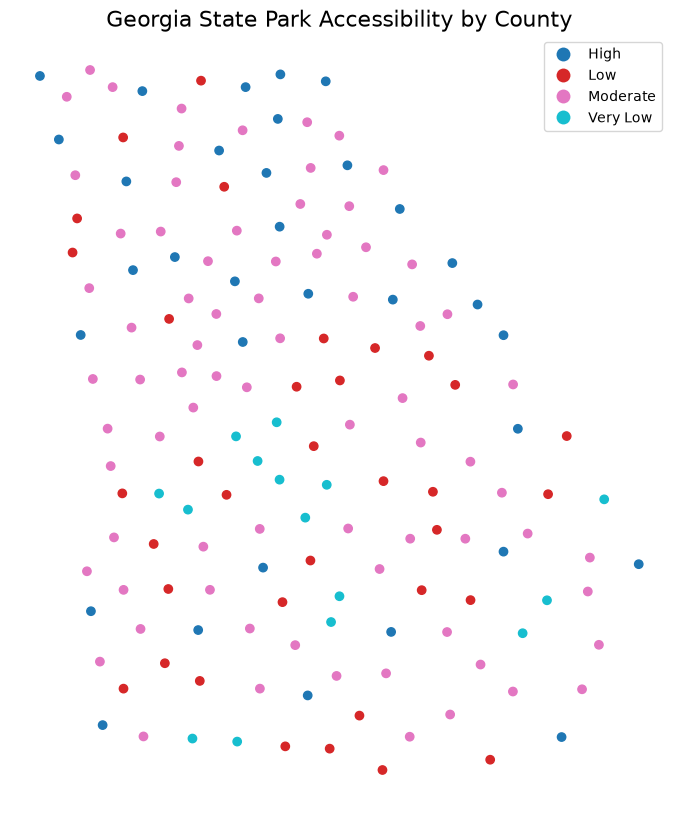

In [264]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

access_map.plot(
    column="access_category",
    categorical=True,
    legend=True,
    figsize=(10,10),
    ax=ax
)

ax.set_title(
    "Georgia State Park Accessibility by County",
    fontsize=16
)

ax.axis("off")

plt.show()

In [265]:
park_points = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_points.gpkg",
    layer="park_points"
)

DataSourceError: C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_points.gpkg: No such file or directory

In [266]:
park_points = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_points.gpkg",
    layer="park_points"
)

DataSourceError: C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_points.gpkg: No such file or directory

In [267]:
park_points.head()

,NAME,geometry,AREA,PERIMETER,DNR20A_,DNR20A_ID,MANAGING_A,MANAGER_CO,OWNER_CODE
0,A. H. STEPHENS SP,POINT (324084.481 3716159.313),323345.0,2568.86,249,248,Georgia Department of Natural Resources,3100,3100
1,AMICALOLA FALLS SP,POINT (202681.123 3829625.281),477340.0,3166.22,99,98,Georgia Department of Natural Resources,3100,3100
2,BALLS FERRY SP,POINT (316006.459 3629706.96),2125790.0,6196.31,346,345,Georgia Department of Natural Resources,3100,3100
3,BLACK ROCK MOUNTAIN SP,POINT (279709.259 3865740.788),6900520.0,20265.90,13,12,Georgia Department of Natural Resources,3100,3100
4,BUSH HEAD SHOALS SP,POINT (120783.224 3693362.276),2613720.0,20492.20,264,263,Georgia Department of Natural Resources,3100,3100


In [268]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_exit_code', '_i2', 'pygris', 'ca_tracts', '_2', '_i3', '_3', '_i4', 'os', '_i5', 'gpd', '_i6', '_i7', '_i8', '_i9', '_i10', '_i11', '_11', '_i12', '_12', '_i13', '_i14', '_i15', 'counties', '_i16', '_16', '_i17', '_17', '_i18', '_18', '_i19', '_19', '_i20', '_20', '_i21', '_21', '_i22', '_22', '_i23', '_i24', '_24', '_i25', '_25', '_i26', '_i27', '_i28', '_28', '_i29', '_29', '_i30', '_i31', '_i32', 'ga_counties', '_i33', '_i34', '_i35', '_i36', 'pd', '_i37', '_i38', '_38', '_i39', '_i40', 'population', '_i41', '_41', '_i42', '_42', '_i43', '_i44', '_i45', '_45', '_i46', '_i47', '_i48', '_i49', '_49', '_i50', '_50', '_i51', '_51', '_i52', '_52', '_i53', 'population_est', '_53', '_i54', 'population_long', '_54', '_i55', '_55', '_i56', '_56', '_i57',

In [269]:
park_points_proj.head()

,NAME,geometry,AREA,PERIMETER,DNR20A_,DNR20A_ID,MANAGING_A,MANAGER_CO,OWNER_CODE
0,A. H. STEPHENS SP,POINT (324084.481 3716159.313),323345.0,2568.86,249,248,Georgia Department of Natural Resources,3100,3100
1,AMICALOLA FALLS SP,POINT (202681.123 3829625.281),477340.0,3166.22,99,98,Georgia Department of Natural Resources,3100,3100
2,BALLS FERRY SP,POINT (316006.459 3629706.96),2125790.0,6196.31,346,345,Georgia Department of Natural Resources,3100,3100
3,BLACK ROCK MOUNTAIN SP,POINT (279709.259 3865740.788),6900520.0,20265.90,13,12,Georgia Department of Natural Resources,3100,3100
4,BUSH HEAD SHOALS SP,POINT (120783.224 3693362.276),2613720.0,20492.20,264,263,Georgia Department of Natural Resources,3100,3100


In [270]:
park_points_proj.shape

(47, 9)

In [271]:
park_points_proj.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_points.gpkg",
    layer="park_points",
    driver="GPKG"
)

In [272]:
park_points = gpd.read_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\park_points.gpkg",
    layer="park_points"
)

park_points.head()

,NAME,AREA,PERIMETER,DNR20A_,DNR20A_ID,MANAGING_A,MANAGER_CO,OWNER_CODE,geometry
0,A. H. STEPHENS SP,323345.0,2568.86,249,248,Georgia Department of Natural Resources,3100,3100,POINT (324084.481 3716159.313)
1,AMICALOLA FALLS SP,477340.0,3166.22,99,98,Georgia Department of Natural Resources,3100,3100,POINT (202681.123 3829625.281)
2,BALLS FERRY SP,2125790.0,6196.31,346,345,Georgia Department of Natural Resources,3100,3100,POINT (316006.459 3629706.96)
3,BLACK ROCK MOUNTAIN SP,6900520.0,20265.90,13,12,Georgia Department of Natural Resources,3100,3100,POINT (279709.259 3865740.788)
4,BUSH HEAD SHOALS SP,2613720.0,20492.20,264,263,Georgia Department of Natural Resources,3100,3100,POINT (120783.224 3693362.276)


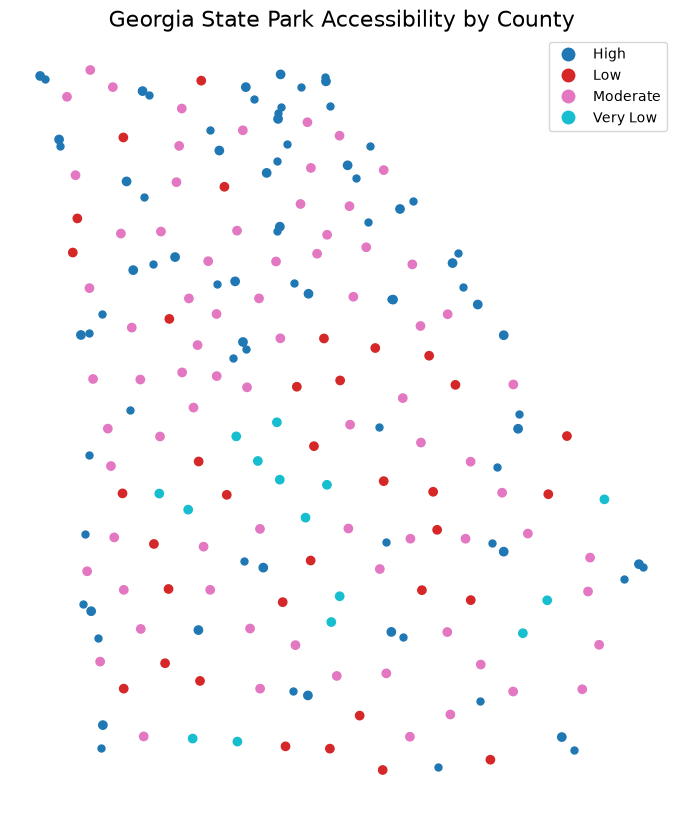

In [273]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

access_map.plot(
    column="access_category",
    categorical=True,
    legend=True,
    ax=ax
)

park_points.plot(
    ax=ax,
    markersize=25
)

ax.set_title(
    "Georgia State Park Accessibility by County",
    fontsize=16
)

ax.axis("off")

plt.show()

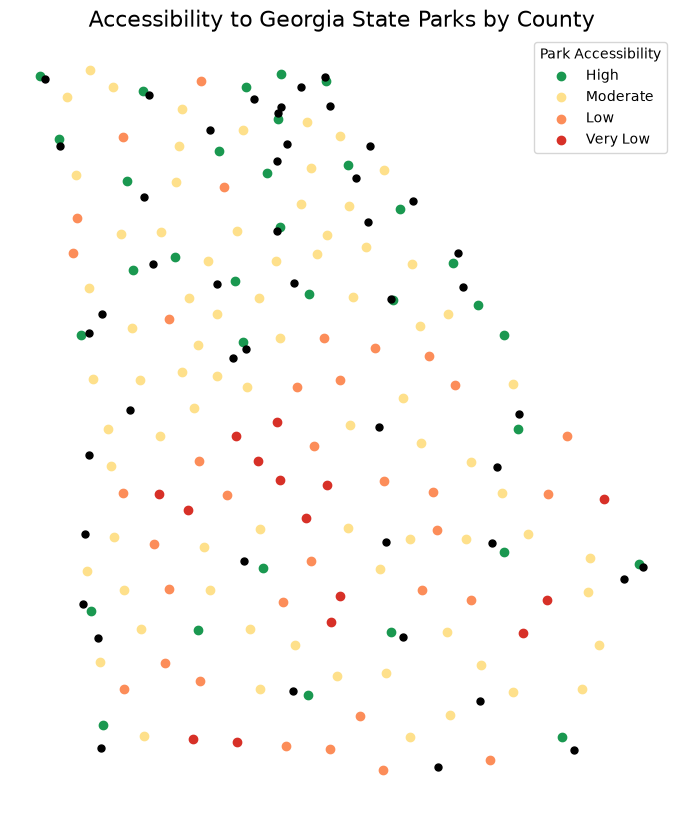

In [274]:
import matplotlib.pyplot as plt

colors = {
    "High": "#1a9850",
    "Moderate": "#fee08b",
    "Low": "#fc8d59",
    "Very Low": "#d73027"
}

fig, ax = plt.subplots(figsize=(10,10))

for category, color in colors.items():
    access_map[
        access_map["access_category"] == category
    ].plot(
        ax=ax,
        color=color,
        label=category
    )

park_points.plot(
    ax=ax,
    color="black",
    markersize=25
)

ax.legend(
    title="Park Accessibility"
)

ax.set_title(
    "Accessibility to Georgia State Parks by County",
    fontsize=16
)

ax.axis("off")

plt.show()

In [275]:
far_access = access_map[
    access_map["access_category"] == "Very Low"
]

far_access[
    ["county", "nearest_park", "distance_miles"]
].sort_values(
    "distance_miles",
    ascending=False
).head(10)

,county,nearest_park,distance_miles
106,Peach,GEORGIA VETERANS SP,42.305812
89,Grady,SEMINOLE SP,38.375761
79,Houston,GEORGIA VETERANS SP,37.184325
39,Wayne,LAURA WALKER SP,33.637226
30,Marion,STANDING BOY CREEK SP,33.555970
124,Long,GORDONIA-ALATAMAHA SP,33.053591
136,Bibb,HIGH FALLS SP,32.526323
0,Effingham,SKIDAWAY ISLAND SP,32.519888
28,Bleckley,BALLS FERRY SP,32.383989
100,Crawford,SPREWELL BLUFF WMA,32.280142


In [276]:
plt.savefig(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\park_accessibility_map.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [277]:
accessibility = accessibility.rename(columns={
    "nearest_park": "nearest_park",
    "distance_miles": "park_distance_miles",
    "Population": "population"
})

accessibility.columns

AttributeError: 'function' object has no attribute 'rename'

In [278]:
accessibility = accessibility.rename(columns={
    "nearest_park": "nearest_park",
    "distance_miles": "park_distance_miles",
    "Population": "population"
})

accessibility.columns

AttributeError: 'function' object has no attribute 'rename'

In [279]:
type(accessibility)

function

In [280]:
accessibility = access_population_clean.copy()

accessibility.head()

,county,nearest_park,distance_miles,Population,access_category,geometry
0,Effingham,SKIDAWAY ISLAND SP,32.519888,67265,Very Low,POINT (467893.148 3581190.647)
1,Schley,GEORGIA VETERANS SP,31.930899,4539,Very Low,POINT (187725.214 3574263.765)
2,Hart,TUGALOO SP,11.594498,26484,Moderate,POINT (319341.683 3802808.553)
3,Oconee,HARD LABOR CREEK SP,15.443174,42788,Moderate,POINT (274489.185 3746525.041)
4,Brooks,REED BINGHAM SP,23.332976,16285,Low,POINT (253232.357 3414927.603)


In [281]:
type(accessibility)

geopandas.geodataframe.GeoDataFrame

In [282]:
accessibility = accessibility.rename(columns={
    "distance_miles": "park_distance_miles",
    "Population": "population"
})

accessibility.columns

Index(['county', 'nearest_park', 'park_distance_miles', 'population',
       'access_category', 'geometry'],
      dtype='str')

In [283]:
type(access_population_clean)

geopandas.geodataframe.GeoDataFrame

In [284]:
accessibility = access_population_clean.copy()

accessibility.head()

,county,nearest_park,distance_miles,Population,access_category,geometry
0,Effingham,SKIDAWAY ISLAND SP,32.519888,67265,Very Low,POINT (467893.148 3581190.647)
1,Schley,GEORGIA VETERANS SP,31.930899,4539,Very Low,POINT (187725.214 3574263.765)
2,Hart,TUGALOO SP,11.594498,26484,Moderate,POINT (319341.683 3802808.553)
3,Oconee,HARD LABOR CREEK SP,15.443174,42788,Moderate,POINT (274489.185 3746525.041)
4,Brooks,REED BINGHAM SP,23.332976,16285,Low,POINT (253232.357 3414927.603)


In [285]:
accessibility = accessibility.rename(columns={
    "distance_miles": "park_distance_miles",
    "Population": "population"
})

accessibility.columns

Index(['county', 'nearest_park', 'park_distance_miles', 'population',
       'access_category', 'geometry'],
      dtype='str')

In [286]:
accessibility.to_file(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\state_park_accessibility.gpkg",
    layer="county_accessibility",
    driver="GPKG"
)

In [287]:
accessibility.crs

<Projected CRS: EPSG:26917>
Name: NAD83 / UTM zone 17N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 84°W and 78°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Florida; Georgia; Kentucky; Maryland; Michigan; New York; North Carolina; Ohio; Pennsylvania; South Carolina; Tennessee; Virginia; West Virginia.
- bounds: (-84.0, 23.81, -78.0, 84.0)
Coordinate Operation:
- name: UTM zone 17N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [288]:
accessibility_map = accessibility.to_crs(epsg=4326)

accessibility_map.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

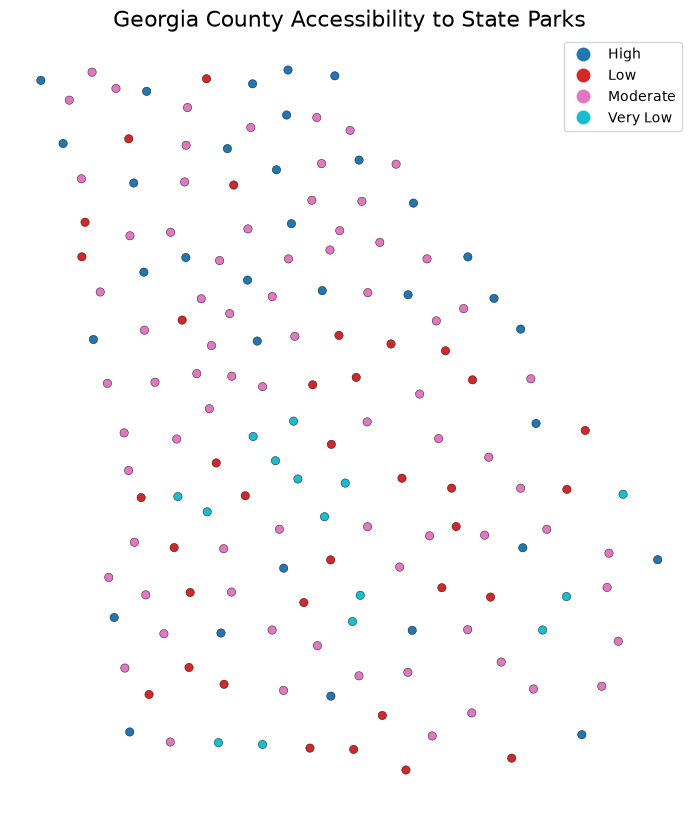

In [289]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

accessibility_map.plot(
    column="access_category",
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

plt.title(
    "Georgia County Accessibility to State Parks",
    fontsize=16
)

plt.axis("off")

plt.show()

In [290]:
accessibility_map = accessibility.to_crs(epsg=4326)

<Axes: >

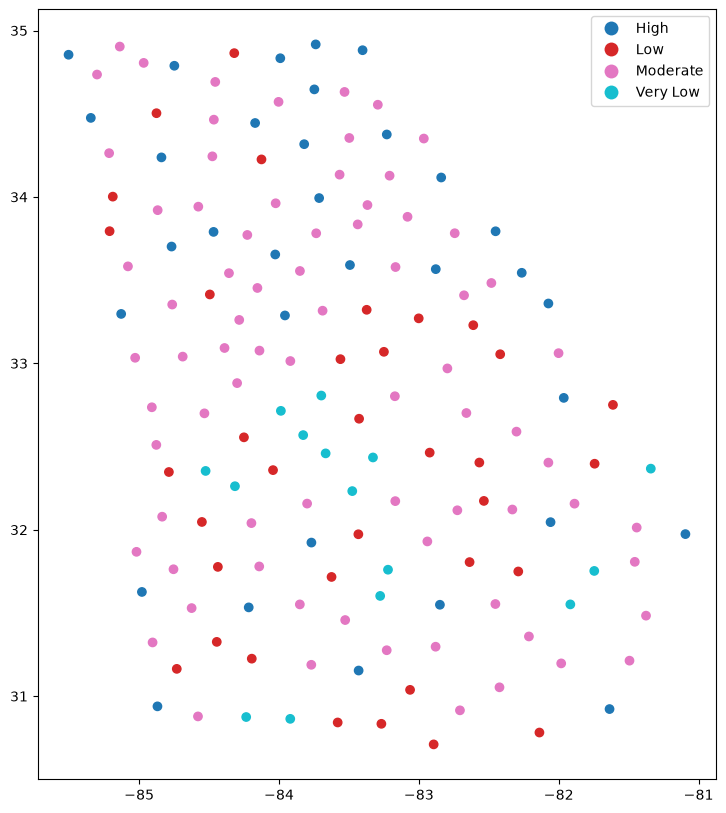

In [291]:
accessibility_map.plot(
    column="access_category",
    legend=True,
    figsize=(10,10)
)

<Axes: >

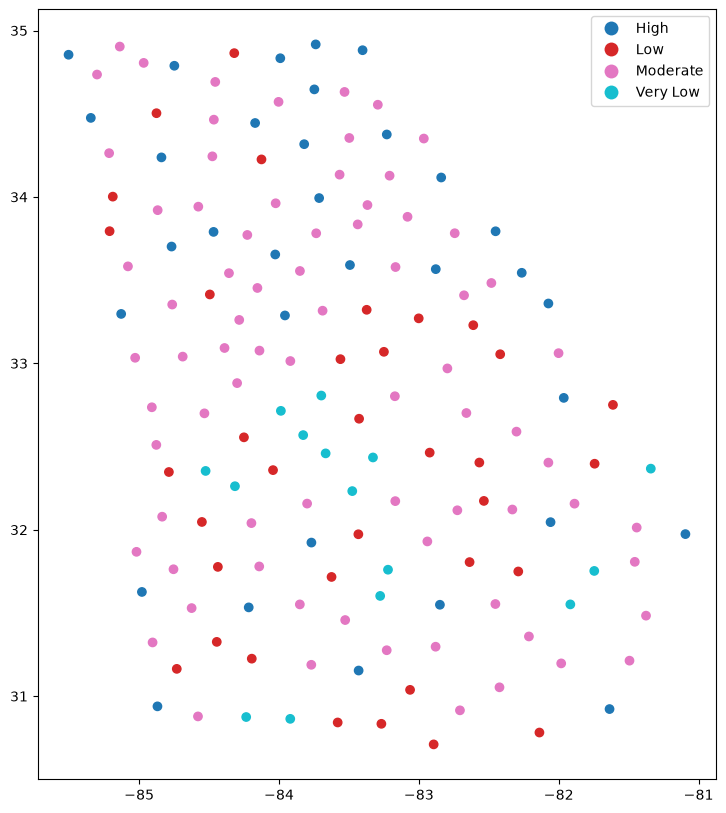

In [291]:
accessibility_map.plot(
    column="access_category",
    legend=True,
    figsize=(10,10)
)

In [292]:
x = 1

In [293]:
accessibility_map = accessibility.to_crs(epsg=4326)

<Axes: >

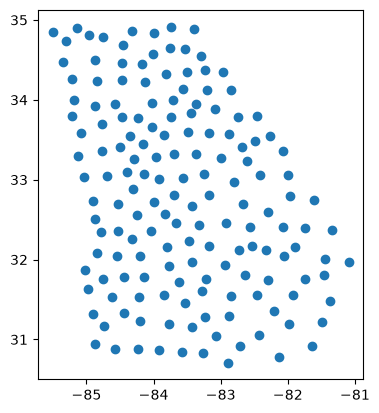

In [294]:
accessibility_map.plot()

In [295]:
import pandas as pd
population = pd.read_csv("your_file_name.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'your_file_name.csv'

In [296]:
import pandas as pd
population = pd.read_csv("state_park_accessibility.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'state_park_accessibility.csv'

In [297]:
import os
os.getcwd()


'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity'

In [298]:
import pandas as pd

population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\state_park_accessibility.csv"
)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity\\state_park_accessibility.csv'

In [299]:
import os
os.listdir(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio")


['Project 1 - State Park Accessibillity']

In [300]:
os.listdir(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibility")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibility'

In [301]:
import os
os.listdir(r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed")


['county_state_park_access.cpg',
 'county_state_park_access.dbf',
 'county_state_park_access.gpkg',
 'county_state_park_access.prj',
 'county_state_park_access.shp',
 'county_state_park_access.shx',
 'ga_counties.cpg',
 'ga_counties.dbf',
 'ga_counties.prj',
 'ga_counties.shp',
 'ga_counties.shx',
 'georgia_county_population.csv',
 'georgia_population_counties.geojson',
 'georgia_state_parks.cpg',
 'georgia_state_parks.dbf',
 'georgia_state_parks.prj',
 'georgia_state_parks.shp',
 'georgia_state_parks.shx',
 'park_accessibility.gpkg',
 'park_points.gpkg',
 'state_park_accessibility.gpkg']

In [302]:
population = pd.read_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\THE_ACTUAL_FILE_NAME.csv"
)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\cason\\OneDrive\\Desktop\\GIS Portfolio\\Project 1 - State Park Accessibillity\\data\\processed\\THE_ACTUAL_FILE_NAME.csv'

In [303]:
accessibility_map = accessibility.to_crs(epsg=4326)

accessibility_map.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

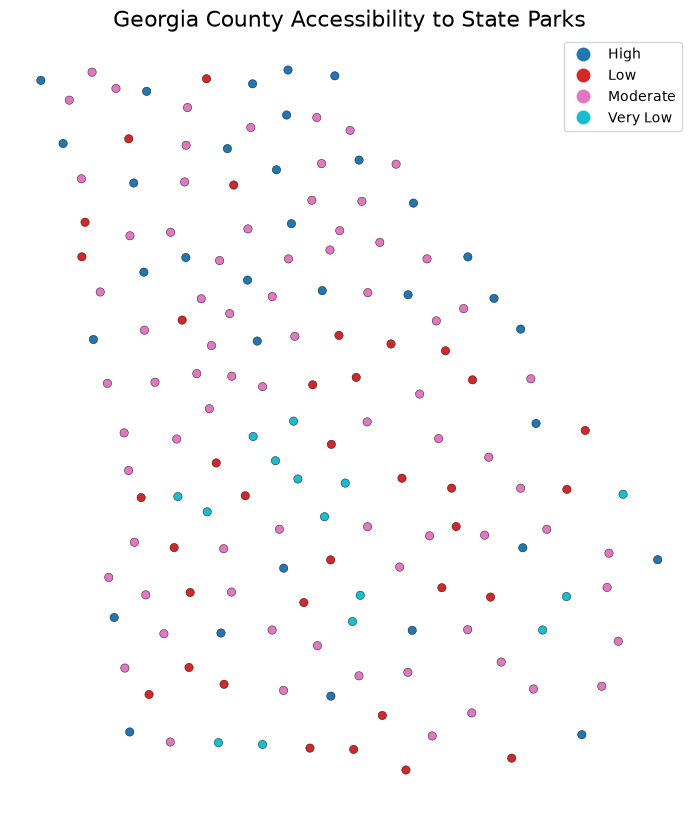

In [304]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

accessibility_map.plot(
    column="access_category",
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

plt.title(
    "Georgia County Accessibility to State Parks",
    fontsize=16
)

plt.axis("off")

plt.show()

In [305]:
type(accessibility_map)

geopandas.geodataframe.GeoDataFrame

In [306]:
accessibility_map.columns

Index(['county', 'nearest_park', 'park_distance_miles', 'population',
       'access_category', 'geometry'],
      dtype='str')

In [307]:
<class 'geopandas.geodataframe.GeoDataFrame'>

SyntaxError: invalid syntax (3599207883.py, line 1)

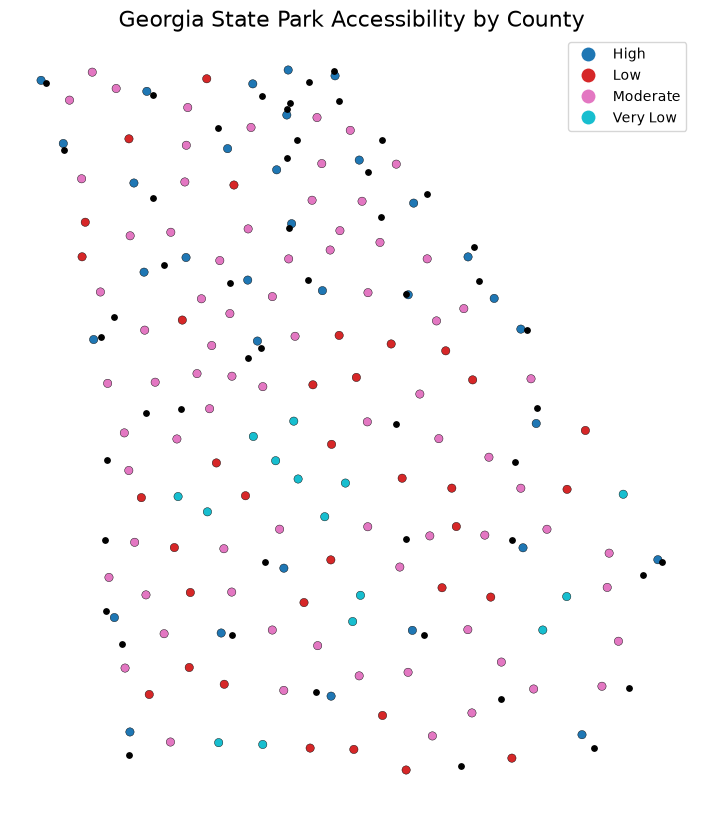

In [308]:
fig, ax = plt.subplots(figsize=(10,10))

# County accessibility layer
accessibility_map.plot(
    column="access_category",
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

# State park locations
state_park_points.to_crs(epsg=4326).plot(
    ax=ax,
    color="black",
    markersize=15
)

plt.title(
    "Georgia State Park Accessibility by County",
    fontsize=16
)

plt.axis("off")

plt.show()

In [309]:
population_access_summary = (
    accessibility
    .groupby("access_category")["population"]
    .sum()
    .reset_index()
    .sort_values("population", ascending=False)
)

population_access_summary

,access_category,population
2,Moderate,6149092
0,High,2950058
1,Low,1111652
3,Very Low,611788


In [310]:
total_population = population_access_summary["population"].sum()

population_access_summary["percent"] = (
    population_access_summary["population"] / total_population * 100
)

population_access_summary

,access_category,population,percent
2,Moderate,6149092,56.817194
0,High,2950058,27.258336
1,Low,1111652,10.271589
3,Very Low,611788,5.652880


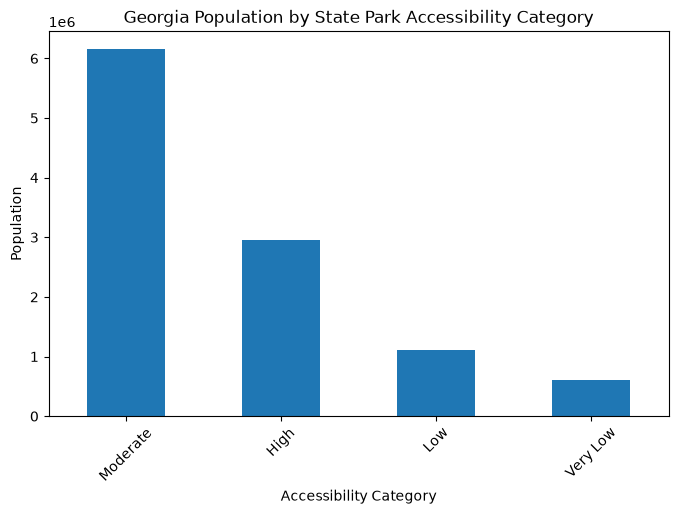

In [311]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

population_access_summary.plot.bar(
    x="access_category",
    y="population",
    ax=ax,
    legend=False
)

plt.title(
    "Georgia Population by State Park Accessibility Category"
)

plt.xlabel("Accessibility Category")
plt.ylabel("Population")

plt.xticks(rotation=45)

plt.show()

In [312]:
priority_counties = accessibility_map[
    accessibility_map["access_category"].isin(
        ["Low", "Very Low"]
    )
]

priority_counties.head()

,county,nearest_park,park_distance_miles,population,access_category,geometry
0,Effingham,SKIDAWAY ISLAND SP,32.519888,67265,Very Low,POINT (-81.34128 32.36721)
1,Schley,GEORGIA VETERANS SP,31.930899,4539,Very Low,POINT (-84.31471 32.26166)
4,Brooks,REED BINGHAM SP,23.332976,16285,Low,POINT (-83.58021 30.84187)
13,Putnam,HARD LABOR CREEK SP,26.384184,22524,Low,POINT (-83.37287 33.32174)
15,Fayette,SWEETWATER CREEK SP,23.991085,120689,Low,POINT (-84.4943 33.41395)


In [313]:
priority_counties.shape

(50, 6)

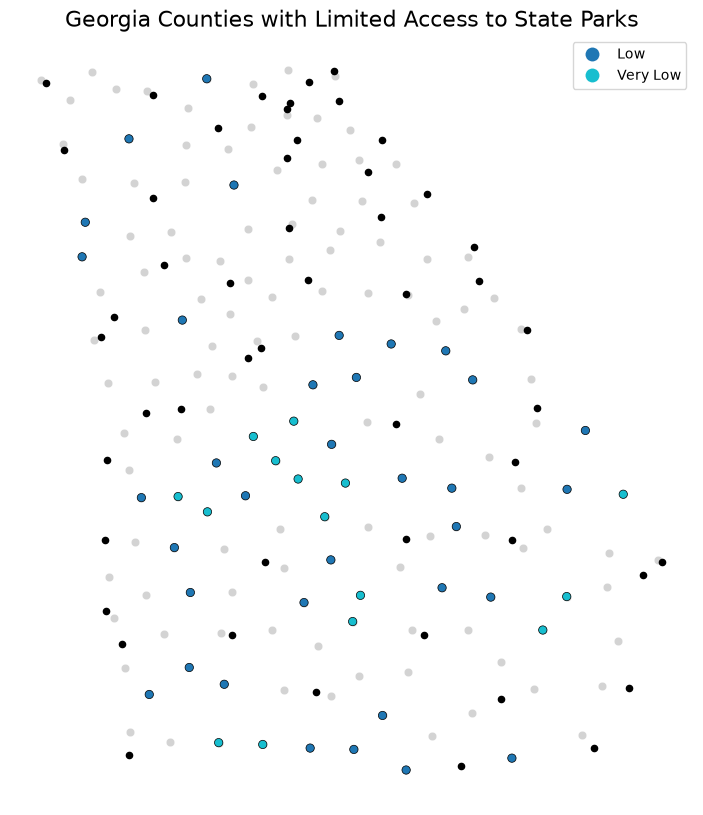

In [314]:
fig, ax = plt.subplots(figsize=(10,10))

# All counties (background)
accessibility_map.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.2
)

# Priority counties
priority_counties.plot(
    column="access_category",
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

# State parks
state_park_points.to_crs(epsg=4326).plot(
    ax=ax,
    color="black",
    markersize=20
)

plt.title(
    "Georgia Counties with Limited Access to State Parks",
    fontsize=16
)

plt.axis("off")

plt.show()

In [315]:
top10_underserved = (
    accessibility
    .sort_values(
        "distance_miles",
        ascending=False
    )
    [
        [
            "county",
            "Population",
            "nearest_park",
            "distance_miles",
            "access_category"
        ]
    ]
    .head(10)
)

top10_underserved

KeyError: 'distance_miles'

In [316]:
top10_underserved = (
    accessibility
    .sort_values(
        "distance_miles",
        ascending=False
    )
    [
        [
            "county",
            "Population",
            "nearest_park",
            "distance_miles",
            "access_category"
        ]
    ]
    .head(10)
)

top10_underserved

KeyError: 'distance_miles'

In [317]:
accessibility.columns

Index(['county', 'nearest_park', 'park_distance_miles', 'population',
       'access_category', 'geometry'],
      dtype='str')

In [318]:
top10_underserved = (
    accessibility
    .sort_values(
        "park_distance_miles",
        ascending=False
    )
    [
        [
            "county",
            "Population",
            "nearest_park",
            "park_distance_miles",
            "access_category"
        ]
    ]
    .head(10)
)

top10_underserved

KeyError: "['Population'] not in index"

In [319]:
accessibility.columns

Index(['county', 'nearest_park', 'park_distance_miles', 'population',
       'access_category', 'geometry'],
      dtype='str')

In [320]:
top10_underserved = (
    accessibility
    .sort_values(
        "park_distance_miles",
        ascending=False
    )
    [
        [
            "county",
            "population",
            "nearest_park",
            "park_distance_miles",
            "access_category"
        ]
    ]
    .head(10)
)

top10_underserved

,county,population,nearest_park,park_distance_miles,access_category
106,Peach,28269,GEORGIA VETERANS SP,42.305812,Very Low
89,Grady,26056,SEMINOLE SP,38.375761,Very Low
79,Houston,166902,GEORGIA VETERANS SP,37.184325,Very Low
39,Wayne,30519,LAURA WALKER SP,33.637226,Very Low
30,Marion,7474,STANDING BOY CREEK SP,33.555970,Very Low
124,Long,17512,GORDONIA-ALATAMAHA SP,33.053591,Very Low
136,Bibb,156543,HIGH FALLS SP,32.526323,Very Low
0,Effingham,67265,SKIDAWAY ISLAND SP,32.519888,Very Low
28,Bleckley,12414,BALLS FERRY SP,32.383989,Very Low
100,Crawford,12183,SPREWELL BLUFF WMA,32.280142,Very Low


In [321]:
top10_underserved_display = top10_underserved.copy()

top10_underserved_display["population"] = (
    top10_underserved_display["population"]
    .astype(int)
    .map("{:,}".format)
)

top10_underserved_display["park_distance_miles"] = (
    top10_underserved_display["park_distance_miles"]
    .round(1)
)

top10_underserved_display

,county,population,nearest_park,park_distance_miles,access_category
106,Peach,"28,269",GEORGIA VETERANS SP,42.3,Very Low
89,Grady,"26,056",SEMINOLE SP,38.4,Very Low
79,Houston,"166,902",GEORGIA VETERANS SP,37.2,Very Low
39,Wayne,"30,519",LAURA WALKER SP,33.6,Very Low
30,Marion,"7,474",STANDING BOY CREEK SP,33.6,Very Low
124,Long,"17,512",GORDONIA-ALATAMAHA SP,33.1,Very Low
136,Bibb,"156,543",HIGH FALLS SP,32.5,Very Low
0,Effingham,"67,265",SKIDAWAY ISLAND SP,32.5,Very Low
28,Bleckley,"12,414",BALLS FERRY SP,32.4,Very Low
100,Crawford,"12,183",SPREWELL BLUFF WMA,32.3,Very Low


In [322]:
top10_underserved_display.to_csv(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\data\processed\top10_underserved_counties.csv",
    index=False
)

In [323]:
plt.show()

In [324]:
plt.savefig(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\maps\accessibility_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [325]:
plt.savefig(
    r"C:\Users\cason\OneDrive\Desktop\GIS Portfolio\Project 1 - State Park Accessibillity\maps\priority_areas_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [326]:
Georgia DNR State Parks
          |
          ↓
Convert park polygons → points
          |
          ↓
Georgia County Boundaries
          |
          ↓
Calculate nearest park distance
          |
          ↓
Join Census Population Data
          |
          ↓
Classify Accessibility
          |
          ↓
Create Maps + Statistics

SyntaxError: invalid character '↓' (U+2193) (3847815325.py, line 3)

In [327]:
flowchart TD

A[Georgia DNR State Parks] --> B[Convert Park Polygons to Representative Points]

B --> C[Georgia County Boundaries]

C --> D[Calculate Nearest Park Distance]

D --> E[Join Census Population Data]

E --> F[Classify Accessibility Categories]

F --> G[Create Maps and Statistical Summaries]

SyntaxError: invalid syntax (3501221547.py, line 1)